# **OkCupid EDA**

# 0. Data Load 및 Train 분리

In [1]:
# 데이터 분석에 사용할 라이브러리
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로딩 관련 라이브러리
import os
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 그래프 고해상도로 변경
%config InlineBackend.figure_format = 'retina'

# 마이너스 기호를 '-'로 표현하도록 변경
mpl.rc('axes', unicode_minus=False)

# 예쁜거
sns.set_theme(style="darkgrid")

In [2]:
# 현재 노트북 기준으로 프로젝트 루트를 찾아서 data 폴더 경로 고정
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data")

# okcupid 데이터셋 불러오기
dataset = pd.read_csv(os.path.join(DATA_PATH, "okcupid_profiles.csv"))

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  str    
 2   sex          59946 non-null  str    
 3   orientation  59946 non-null  str    
 4   body_type    54650 non-null  str    
 5   diet         35551 non-null  str    
 6   drinks       56961 non-null  str    
 7   drugs        45866 non-null  str    
 8   education    53318 non-null  str    
 9   ethnicity    54266 non-null  str    
 10  height       59943 non-null  float64
 11  income       59946 non-null  int64  
 12  job          51748 non-null  str    
 13  last_online  59946 non-null  str    
 14  location     59946 non-null  str    
 15  offspring    24385 non-null  str    
 16  pets         40025 non-null  str    
 17  religion     39720 non-null  str    
 18  sign         48890 non-null  str    
 19  smokes       54

In [3]:
# 기준 시각 개체 생성 (마지막 날짜)
criterion_date = pd.Timestamp("2012-07-01 09:00")

# 마지막 접속 시각 Timestamp 객체로 변환
# last_online은 결측치가 없음
TS_last_online = pd.to_datetime(
    dataset["last_online"],
    format="%Y-%m-%d-%H-%M"
)

# 30일 이상 미접속 여부 (1: 비활동 의심, 0: 그 외)
dataset["churn_suspect"] = (
    (criterion_date - TS_last_online) >= pd.Timedelta(days=30)
).astype(int)

# 75:25
dataset["churn_suspect"].value_counts() / len(dataset)

churn_suspect
0    0.742785
1    0.257215
Name: count, dtype: float64

In [4]:
from common.preprocessing import train_test_split_by_target

df, test = train_test_split_by_target(
    dataset, "churn_suspect", split_target=False
)

df.shape, test.shape

((44959, 32), (14987, 32))

In [5]:
from common.feature_extraction import feature_extraction

train = feature_extraction(df)

# 1. train 데이터 살펴보기

In [6]:
num_li = [np.number, "bool", "boolean"]
df_num = df.select_dtypes(include=num_li)
df_num.describe()
# 109살 할아버지도 이용하는 갓앱
# 신장이 1인치인 태아도 연애에 관심 있음
# 수익이 -1이여도 연애는 하고싶을 수 있지

,age,height,income,churn_suspect
count,44959.000000,44958.000000,44959.000000,44959.000000
mean,32.340710,68.302393,20000.081185,0.257212
std,9.472268,4.019770,97022.702617,0.437102
min,18.000000,1.000000,-1.000000,0.000000
25%,26.000000,66.000000,-1.000000,0.000000
50%,30.000000,68.000000,-1.000000,0.000000
75%,37.000000,71.000000,-1.000000,1.000000
max,110.000000,95.000000,1000000.000000,1.000000


In [7]:
df_str = df.select_dtypes(exclude=num_li)
df_str.iloc[:,:14].describe()
# last_online을 제외하면 범주형 데이터가 맞음.

,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,job,last_online,location,offspring,pets
count,44959,44959,44959,40960,26610,42717,34350,39955,40658,38789,44959,44959,18368,30027
unique,5,2,3,12,18,6,3,32,201,21,24261,176,15,15
top,single,m,straight,average,mostly anything,socially,never,graduated from college/university,white,other,2012-06-30-19-24,"san francisco, california",doesn't have kids,likes dogs and likes cats
freq,41794,26912,38766,10906,12462,31343,28268,17996,24446,5743,20,23273,5737,11100


In [8]:
df_str.iloc[:,14:].describe()
# essay는 사용자가 직접 글을 쓰는 것이니 unique가 많을 수밖에 없음.

,religion,sign,smokes,speaks,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
count,29752,36687,40800,44921,40844,39249,37718,36349,37021,36794,34555,35612,30516,35468
unique,45,48,5,6057,40769,38654,36557,32848,36928,36705,32772,34250,29581,34136
top,agnosticism,gemini and it&rsquo;s fun to think about,no,english,.,enjoying it.,listening,my smile,ask me,my family,my future,out with friends,ask me,you want to.
freq,2018,1332,32895,16357,10,44,61,385,12,5,116,69,36,149


In [9]:
# 결측치 간단 제거
df["age"] = df["age"].where(df["age"].between(18, 70))
df["income"] = df["income"].replace(-1, np.nan)

ESSAY = [f"essay{i}" for i in range(10)]
not_essay_str = df_str.drop(columns=ESSAY)
df[not_essay_str.columns] = df[not_essay_str.columns].fillna("not_disclosed").astype("category")

In [10]:
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False).head(20)

income         80.851442
essay8         32.124825
essay6         23.141084
essay9         21.110345
essay7         20.790053
essay3         19.150782
essay5         18.160991
essay4         17.656087
essay2         16.105785
essay1         12.700460
essay0          9.152784
age             0.004448
height          0.002224
diet            0.000000
body_type       0.000000
status          0.000000
offspring       0.000000
location        0.000000
last_online     0.000000
job             0.000000
dtype: float64

# 2. 공통 출력 함수

In [11]:
def show_hist(x, df=df):
    y = df.groupby(x, observed=True)["churn_suspect"].mean()

    plt.figure(figsize=(12, 5))

    plt.bar(
        [i.mid for i in y.index],
        y.values,
        width=[i.length*0.9 for i in y.index],
        edgecolor="white",
        alpha=0.8
    )

    plt.xlabel(x.name)
    plt.ylabel("Churn Rate")
    plt.title(f"Churn Rate by {x.name}")
    plt.show()


def show_hor_bar(x, df=df):
    y = df.groupby(x, observed=True)["churn_suspect"].mean().sort_values()

    plt.barh(y.index.astype(str), y.values)

    plt.xlabel("Churn Rate")
    plt.ylabel(x.name)
    plt.title(f"Churn Rate by {x.name}")

    plt.tight_layout()
    plt.show()


def show_group_bar(x, df=df, bins=5):
    data = x.copy()
    cols = x.columns.tolist()

    # 수치형인지 판단 (고유값이 적으면 범주형 취급)
    num_cols = [
        col for col in cols
        if pd.api.types.is_numeric_dtype(data[col])
        and data[col].nunique() > 8
    ]

    # 수치형은 자동 구간화
    for col in num_cols:
        data[col] = pd.cut(data[col], bins=bins)

    # 수치형을 X축으로 우선 배치
    x_col = num_cols[0] if num_cols else cols[0]
    hue_col = next(col for col in cols if col != x_col)

    data["churn_suspect"] = df.loc[data.index, "churn_suspect"]

    plt.figure(figsize=(12, 5))

    sns.barplot(
        data=data,
        x=x_col,
        y="churn_suspect",
        hue=hue_col,
        errorbar=None
    )

    plt.xlabel(x_col)
    plt.ylabel("Churn Rate")
    plt.title(f"Churn Rate by {x_col} and {hue_col}")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


def show_box(x):
    plt.figure(figsize=(5, 6))

    sns.boxplot(
        y=x.dropna()
    )

    plt.xlabel(x.name)
    plt.ylabel("Value")
    plt.title(f"{x.name} Distribution")

    plt.show()

# 3. EDA

## age

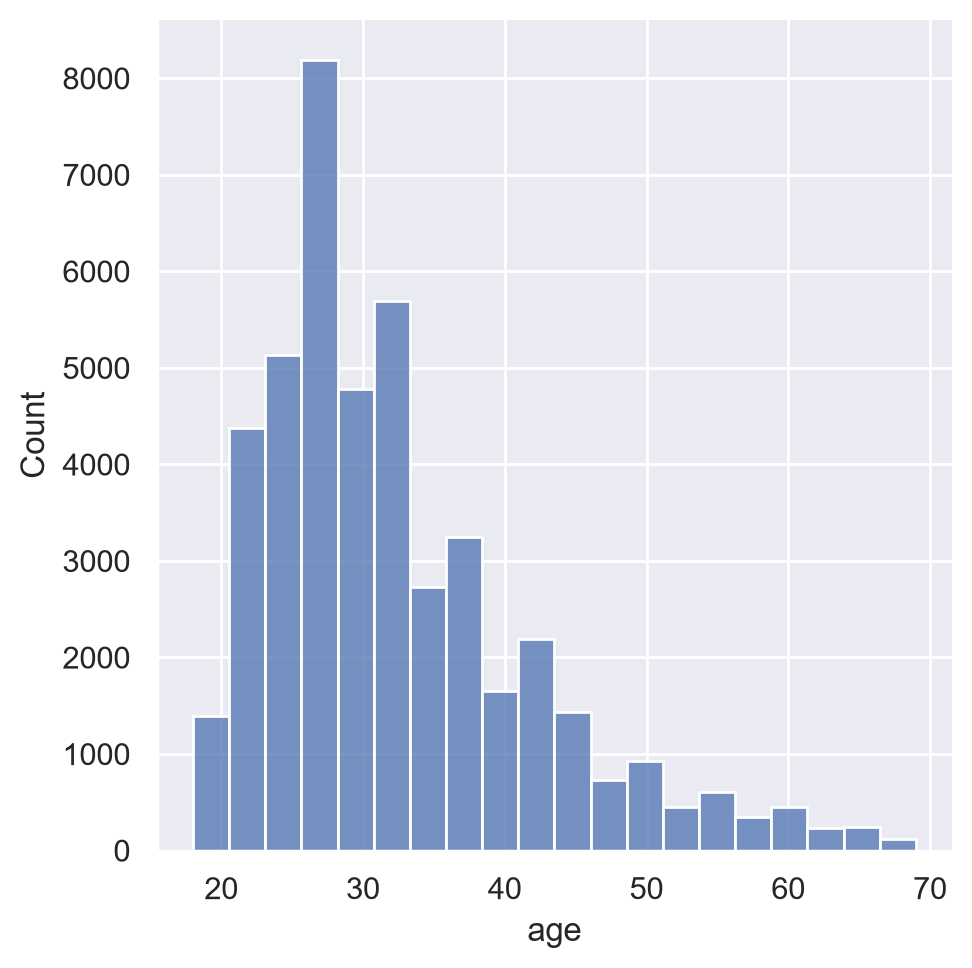

In [12]:
sns.displot(data=df, x='age', bins=20)

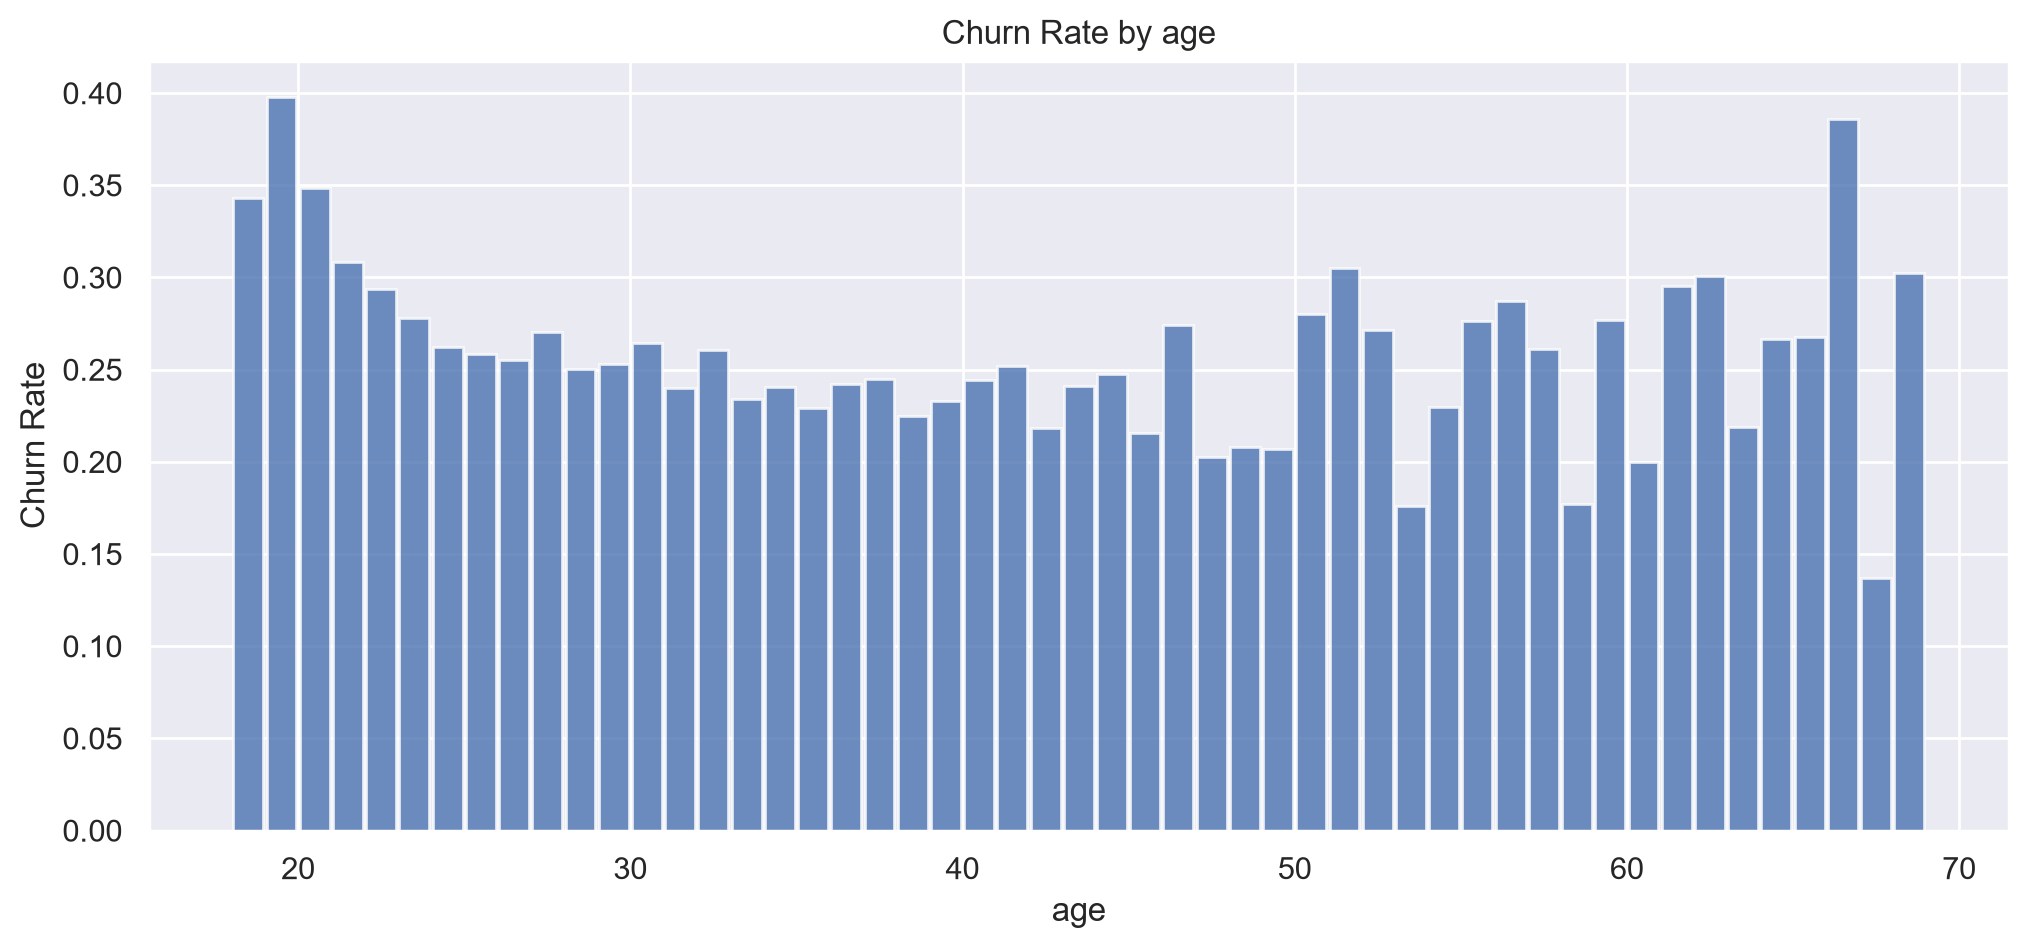

In [13]:
# 5살 단위로 나이 구간 생성
age_bins = pd.cut(
    df["age"],
    bins=range(18, 70),
    right=False
)

show_hist(age_bins)

## status
> 현재 관계 상태

In [14]:
df["status"].value_counts() / df.shape[0] * 100

status
single            92.960253
seeing someone     3.465380
available          2.998287
married            0.558286
unknown            0.017794
Name: count, dtype: float64

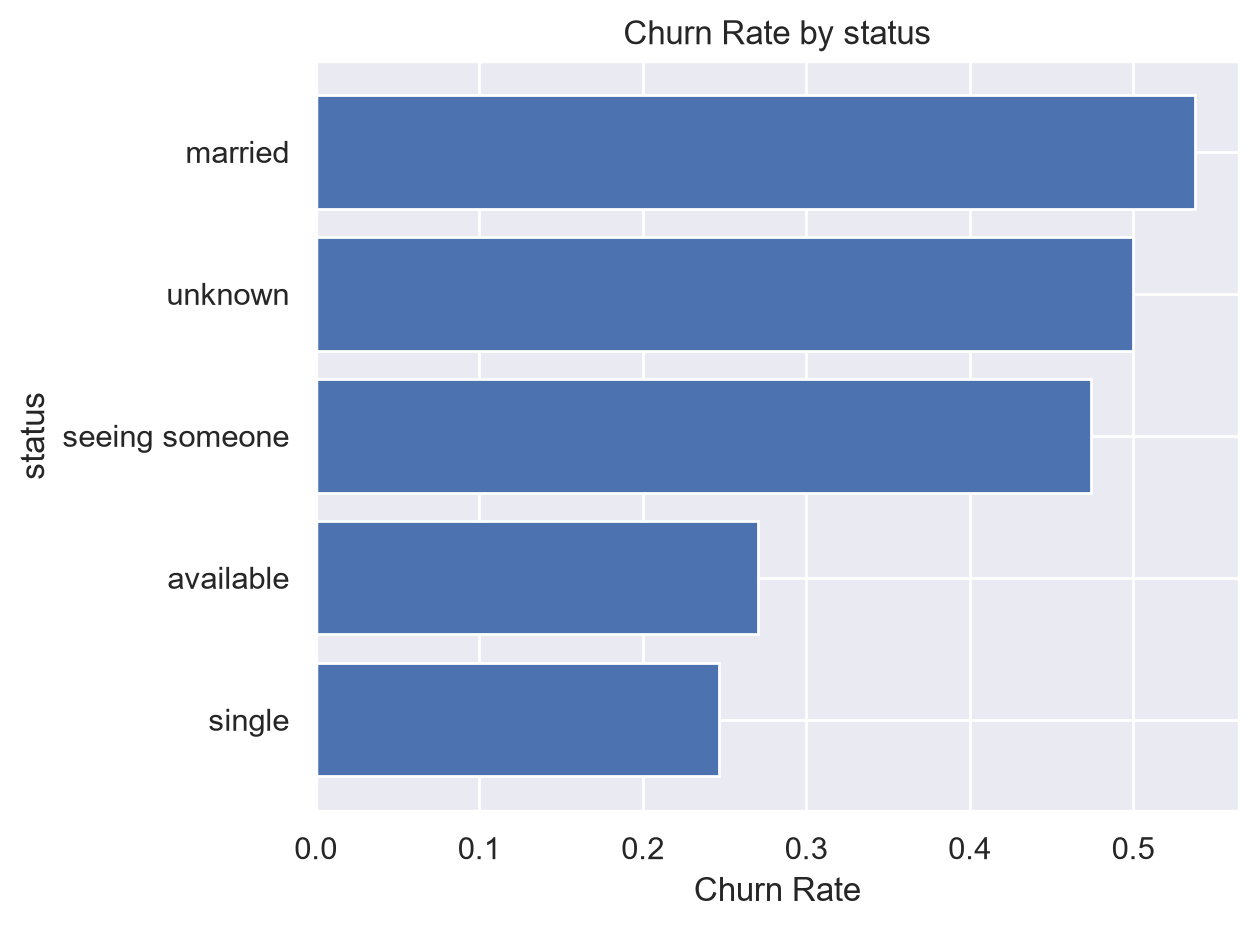

In [15]:
show_hor_bar(df["status"])

## sex (제거한 feature)

In [16]:
df["sex"].value_counts() / df.shape[0] * 100

sex
m    59.858983
f    40.141017
Name: count, dtype: float64

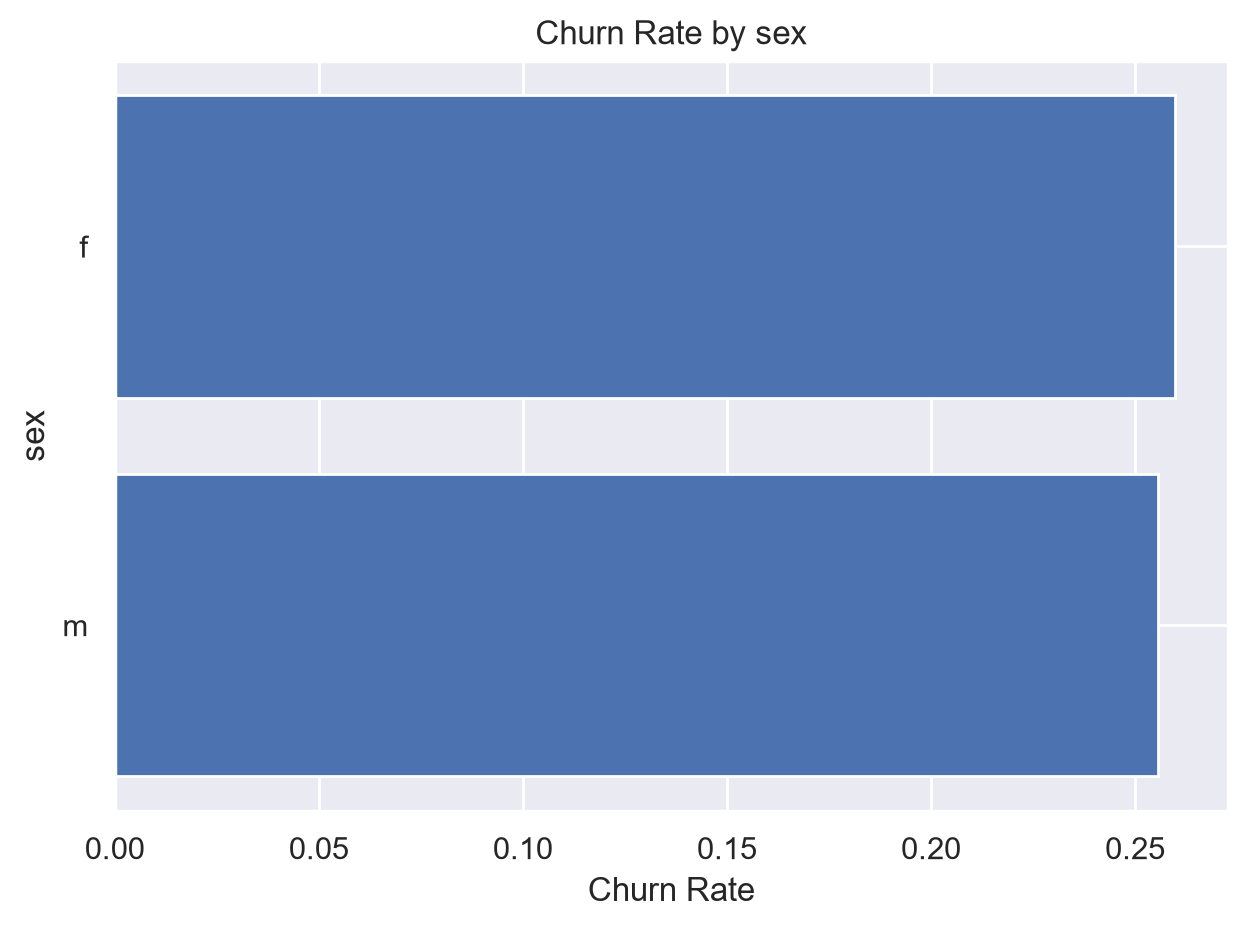

In [17]:
show_hor_bar(df["sex"])

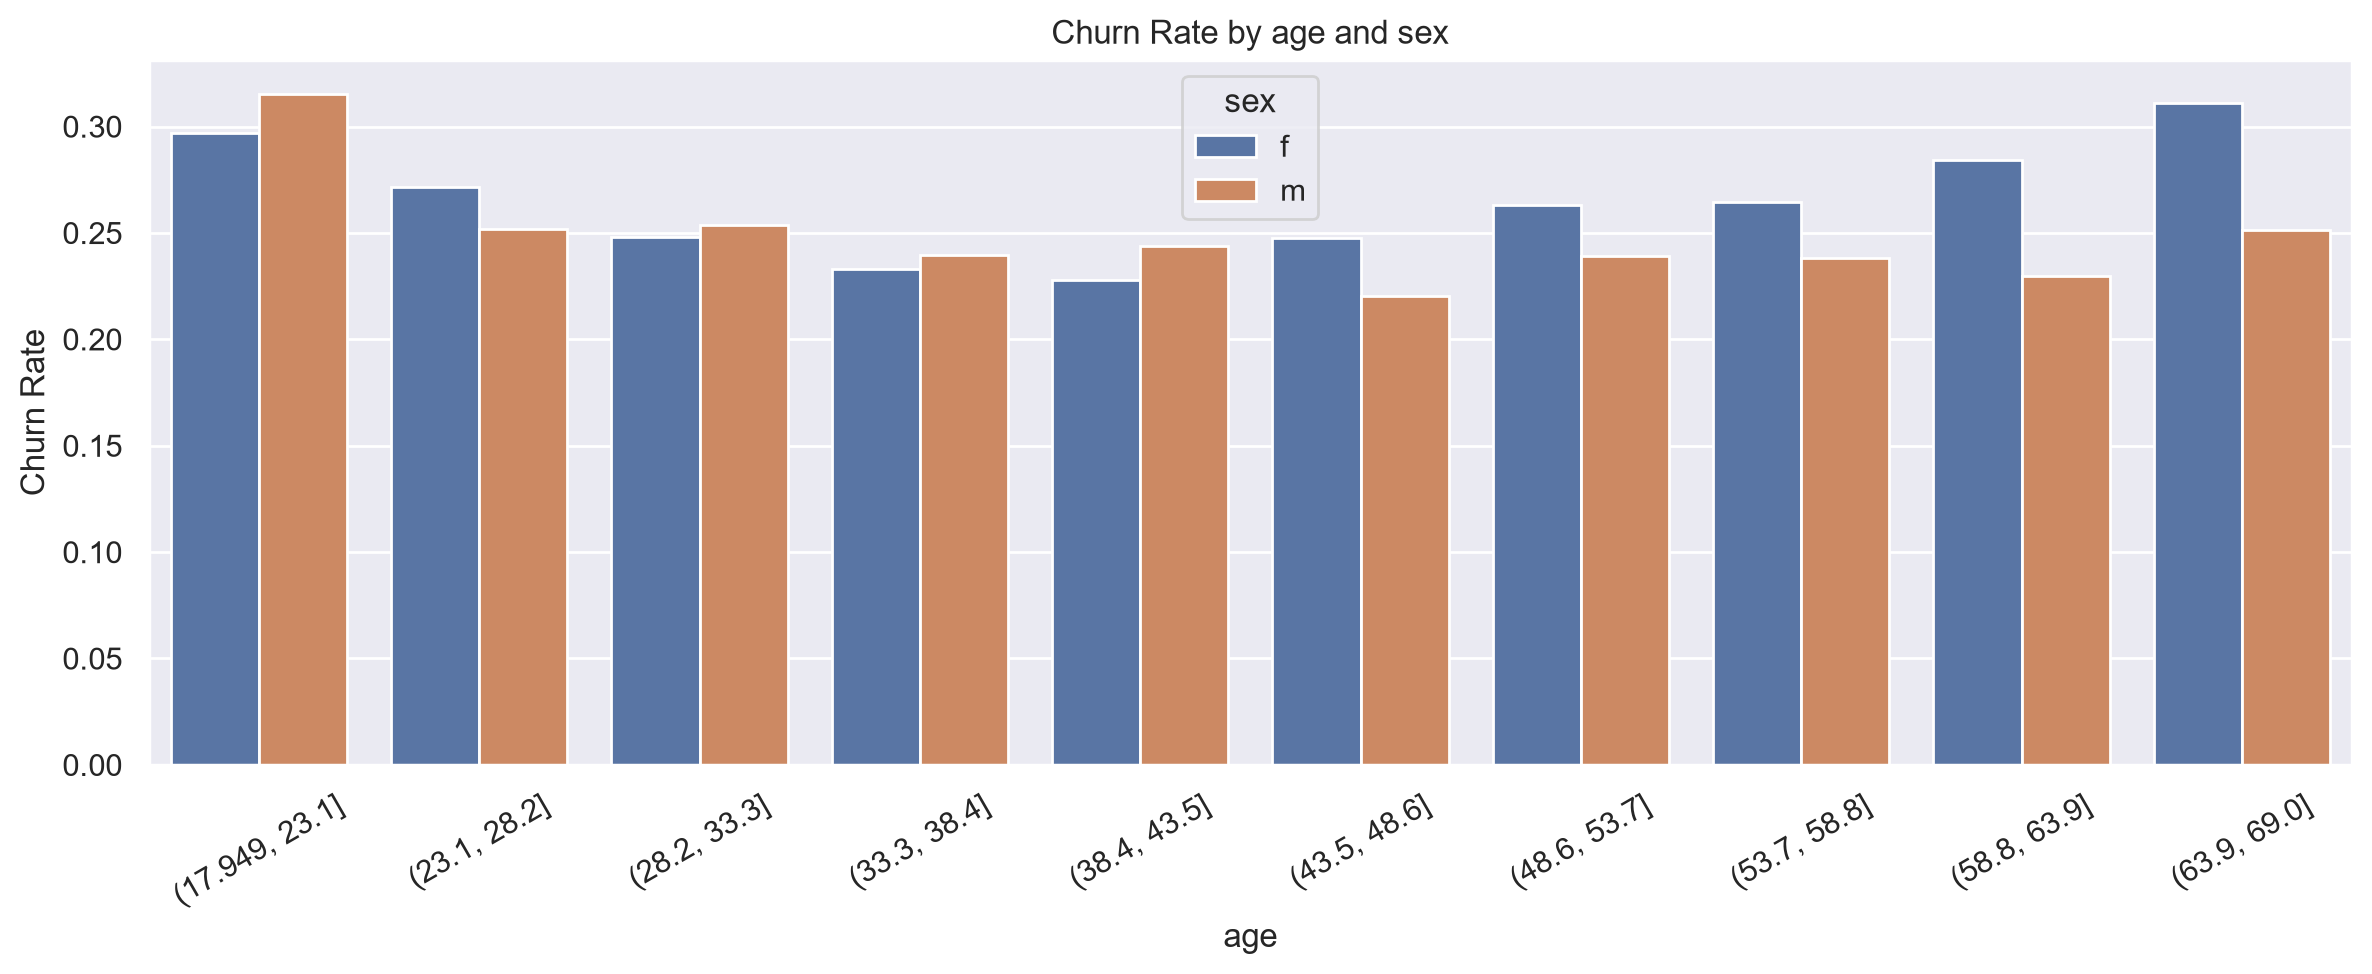

In [18]:
show_group_bar(df[["sex", "age"]], bins=10)

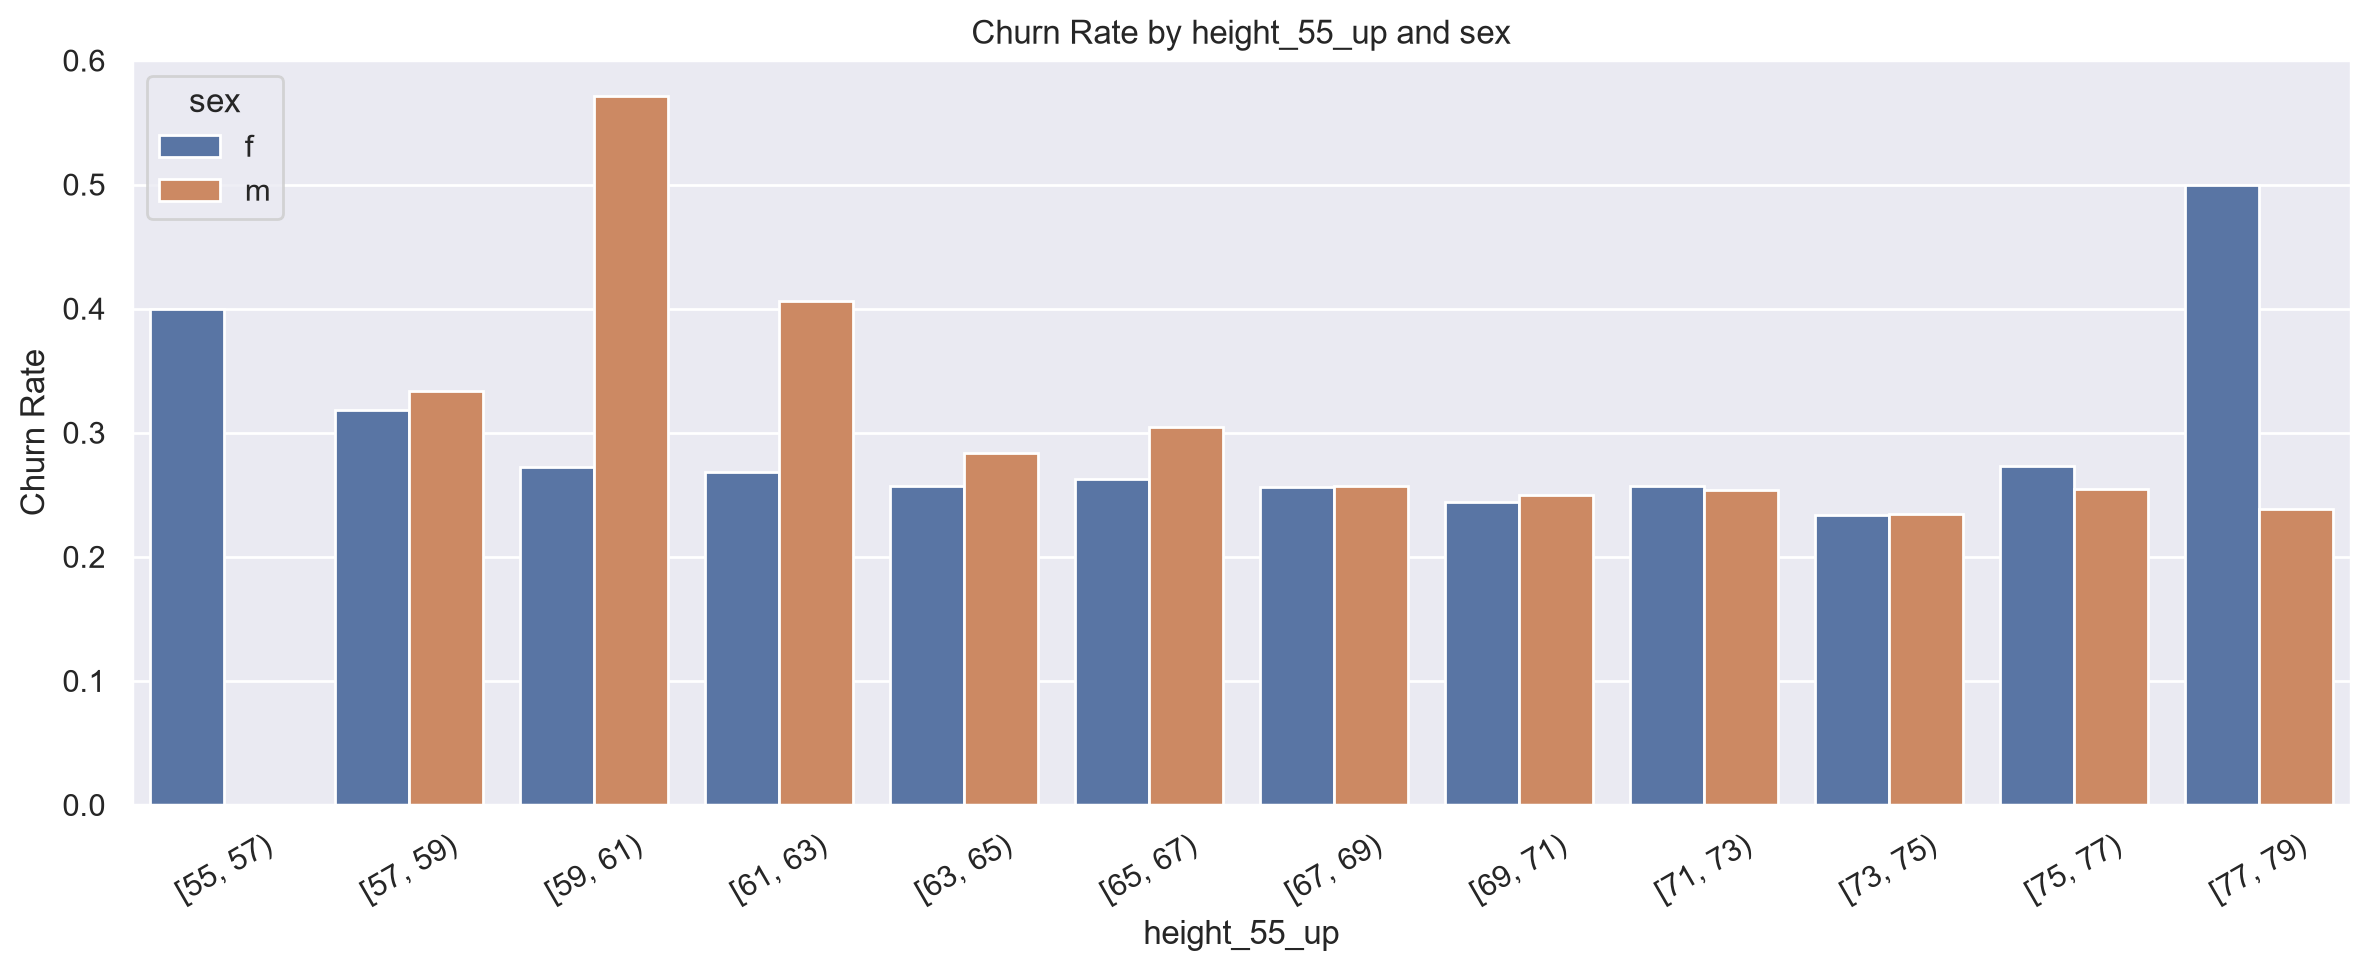

In [19]:
df["height_55_up"] = pd.cut(
    df["height"],
    bins=range(55, 80, 2),     # 55inch ~= 140cm, 67inch ~= 170cm, 79inch ~= 201cm
    right=False
)
show_group_bar(df[["height_55_up", "sex"]], bins=10)

# 18세 이상 하위 1% 남성/여성 키는 각각 156cm (61.4inch), 144cm (56.7inch)
# https://journals.sagepub.com/doi/pdf/10.1177/0018720819839809

## height

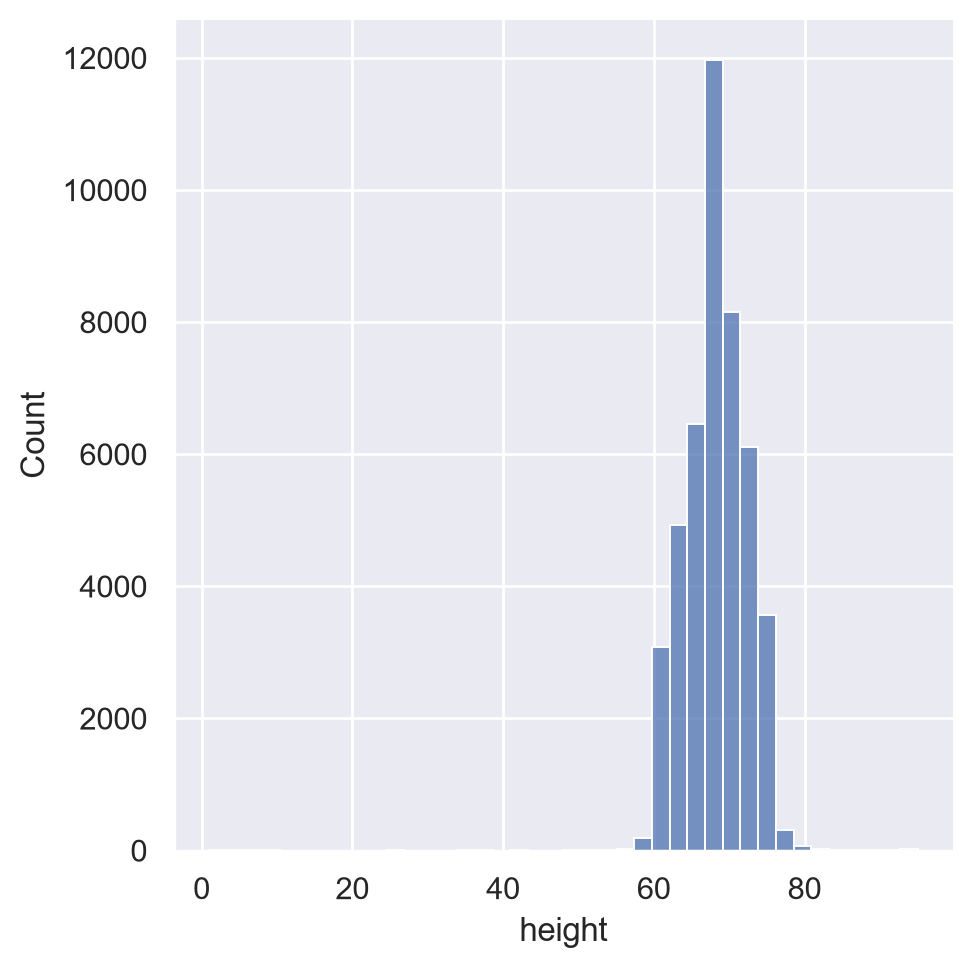

In [20]:
sns.displot(data=df, x='height', bins=40)

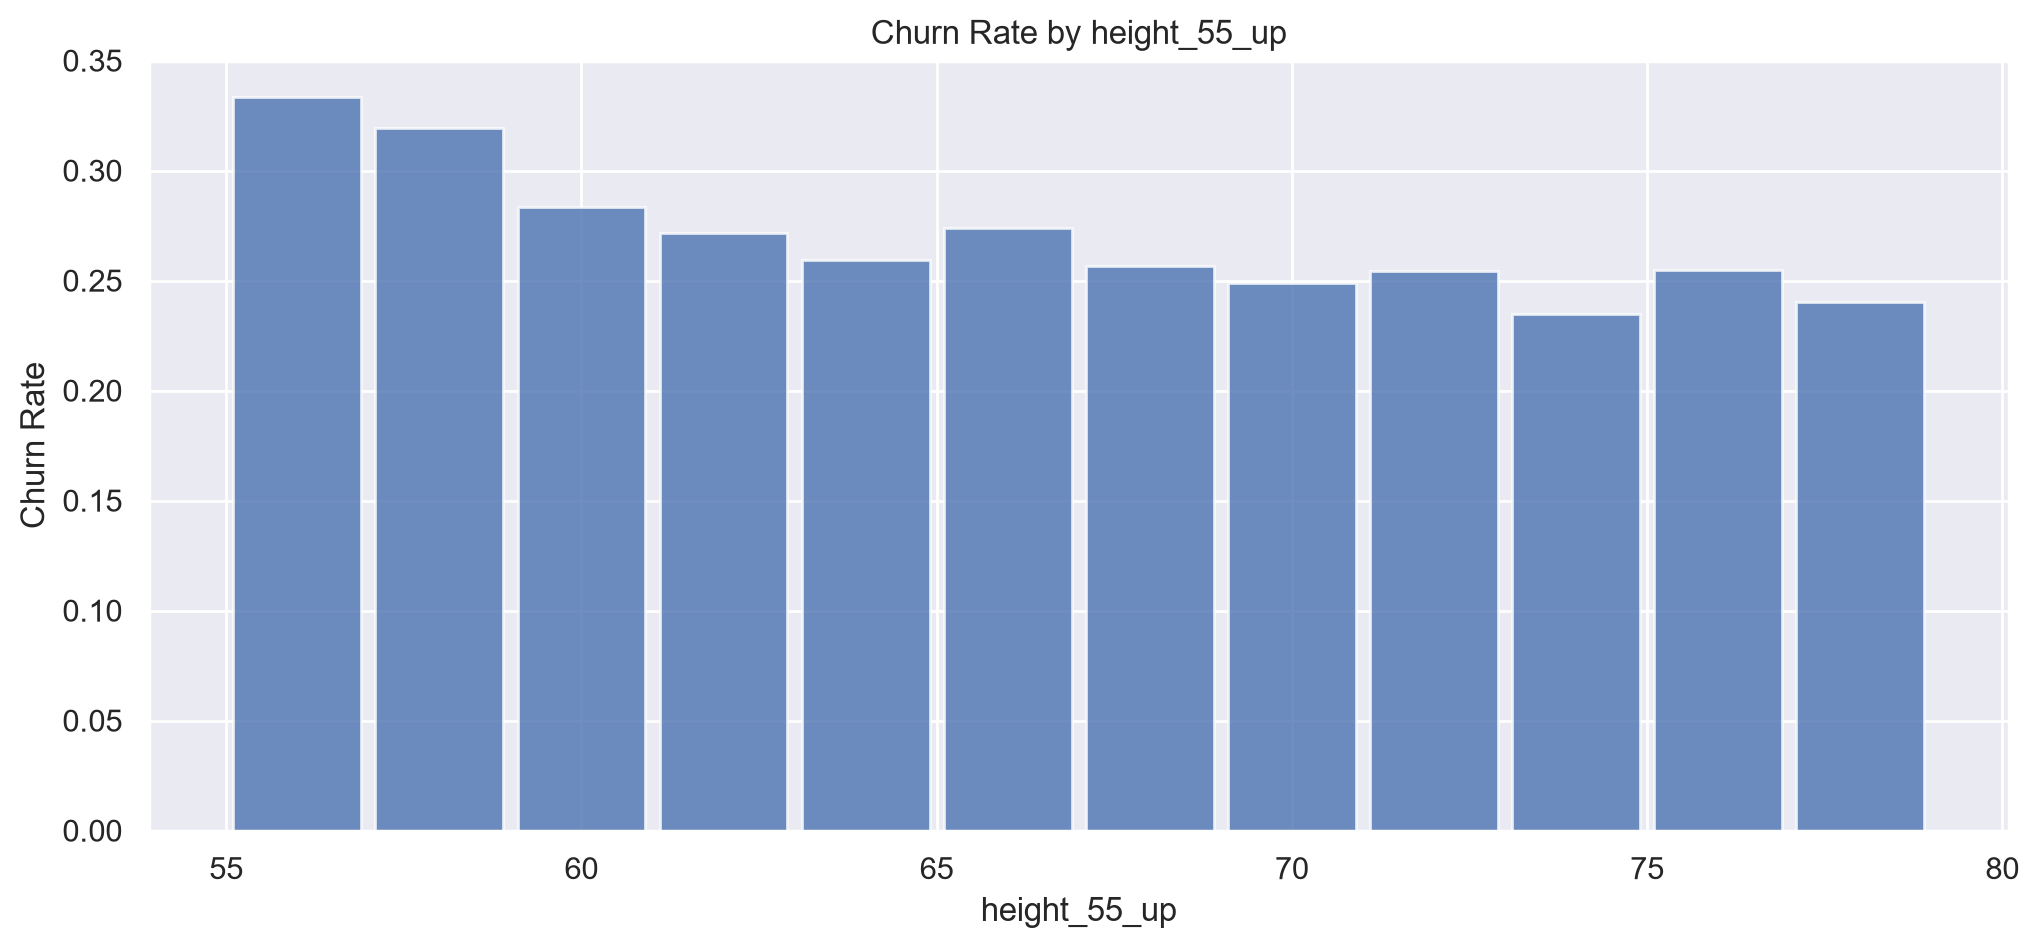

In [21]:
show_hist(df["height_55_up"])

## orientation (제거한 feature)

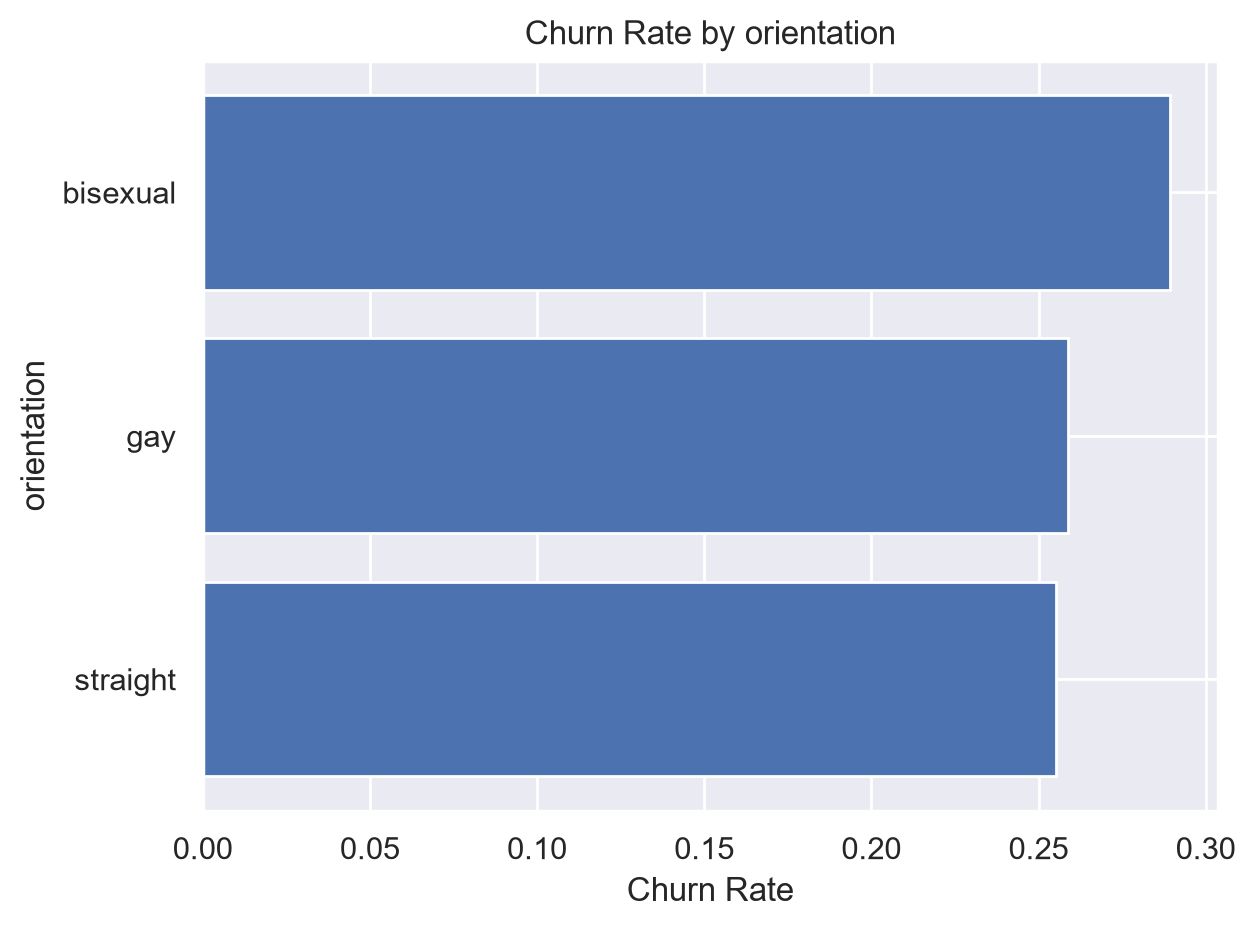

In [22]:
show_hor_bar(df["orientation"])

## body_type (제거한 feature)

In [23]:
df["body_type"].value_counts()

body_type
average           10906
fit                9571
athletic           8878
not_disclosed      3999
thin               3500
curvy              2985
a little extra     1950
skinny             1327
full figured        761
overweight          331
jacked              320
used up             271
rather not say      160
Name: count, dtype: int64

In [24]:
body_group = df["body_type"].isin([
    "a little extra", "full figured", "overweight", "used up"
])

body_group.value_counts() / df.shape[0] * 100

body_type
False    92.631064
True      7.368936
Name: count, dtype: float64

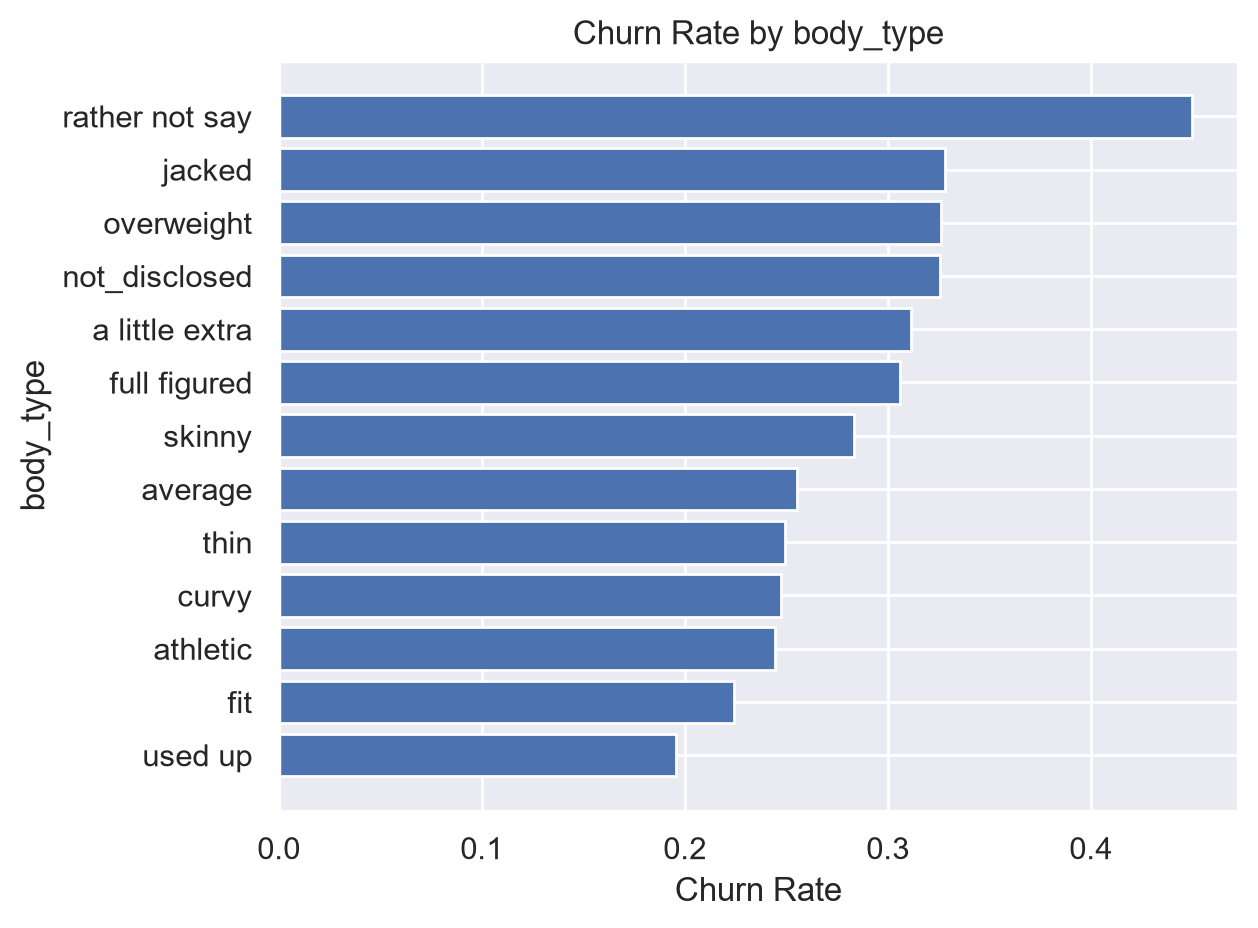

In [25]:
show_hor_bar(df["body_type"])

# full figured, little extra, overweight, used up : 뚱
# curvy, thin, skinny : 마름
# athletic, fit, jacked : 근육질

# 미응답 또는 평균 이상이라고 답한 사람이 92.6% 이므로 큰 도움을 주지 못함
# 아마도 자신을 부풀린 사람이 많기에 이상치라고 생각함.

## diet (컬럼을 분리)

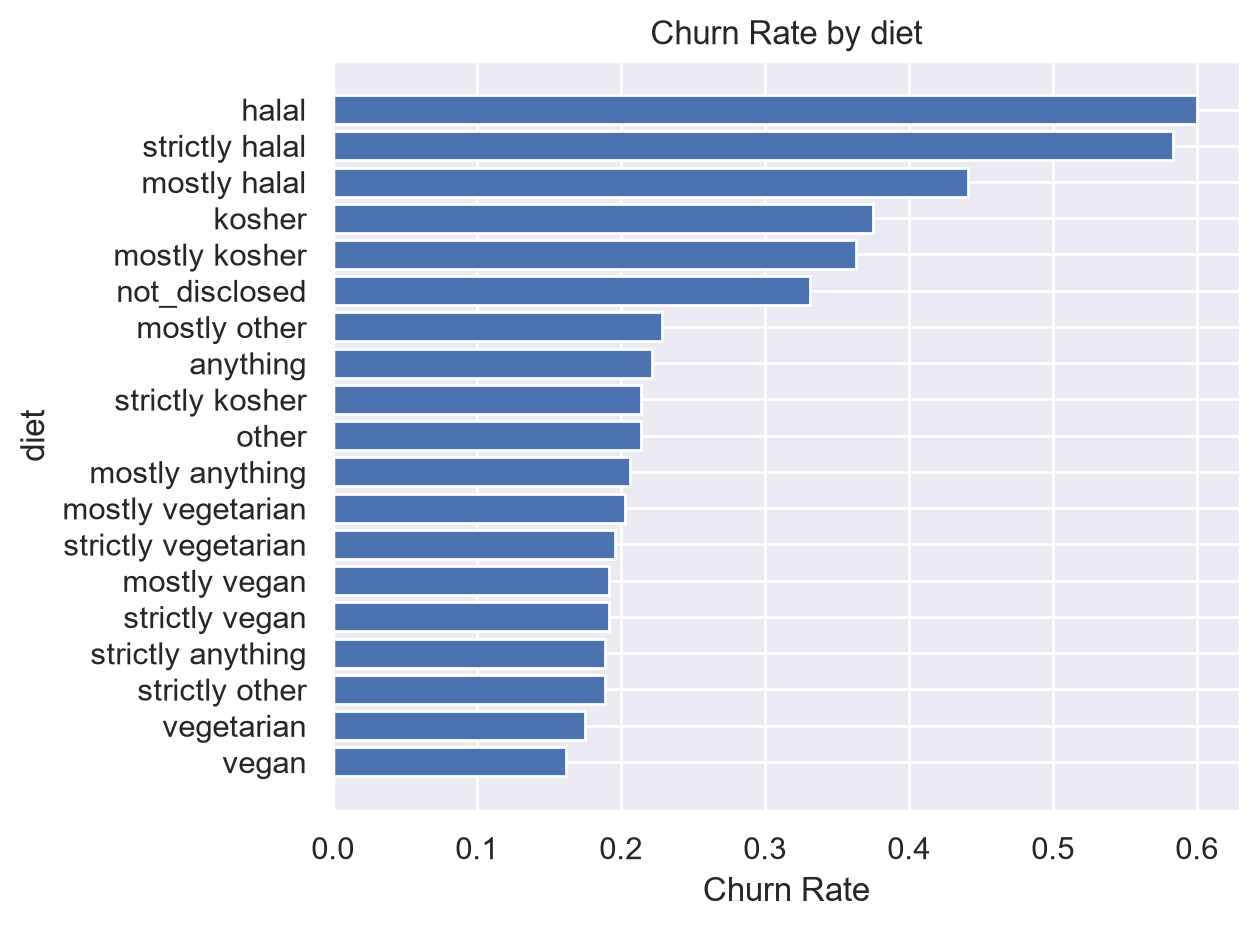

In [26]:
show_hor_bar(df["diet"])

### diet_type (유형)

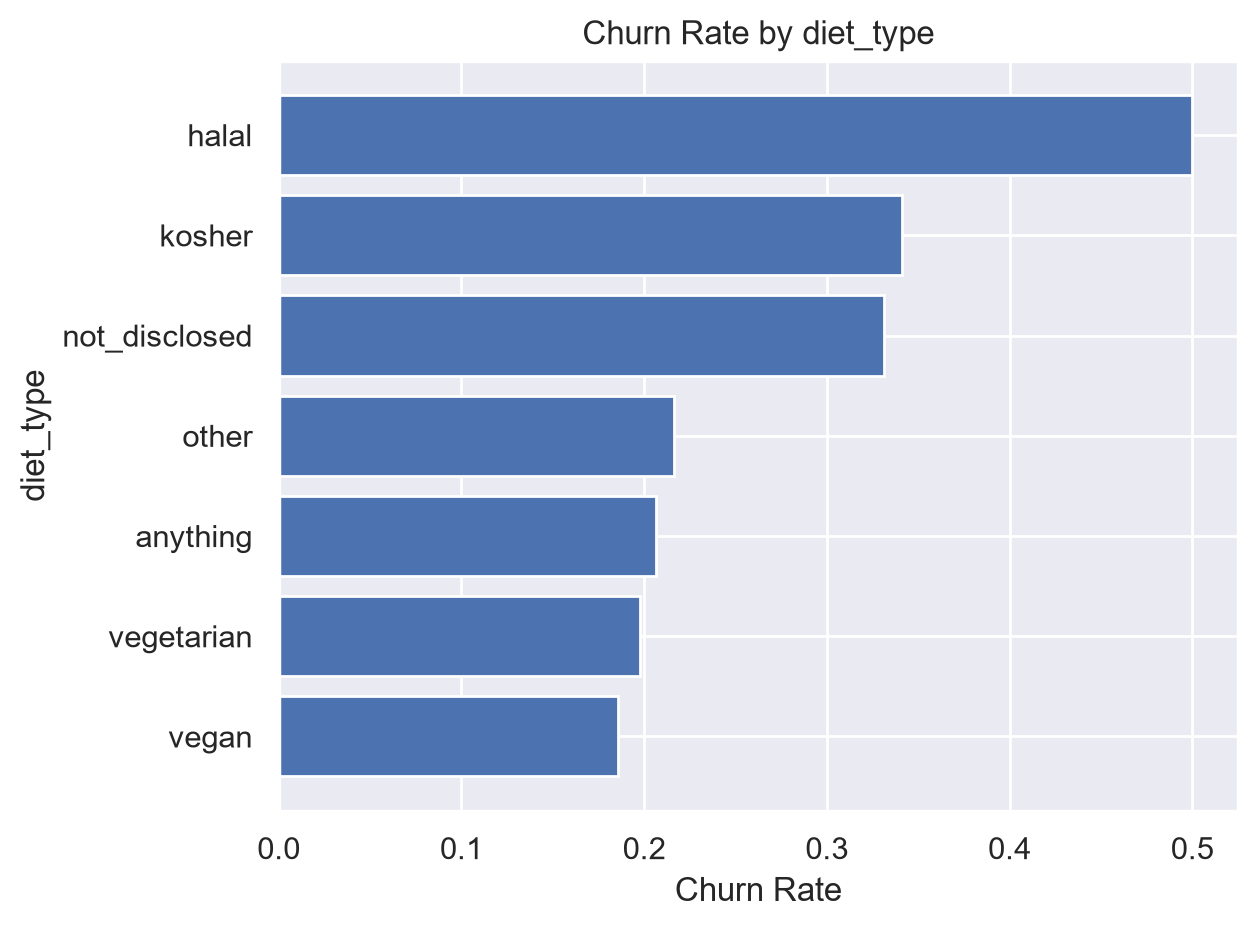

In [27]:
df["diet_type"] = df["diet"].str.replace(r"^(?:mostly|strictly) ", "", regex=True)
show_hor_bar(df["diet_type"])

# halal : 이슬람교 식단
# kosher : 유대교 식단
# vegan, vegetarian : 채식주의 식단

### diet_strict (식이 준수 정도)

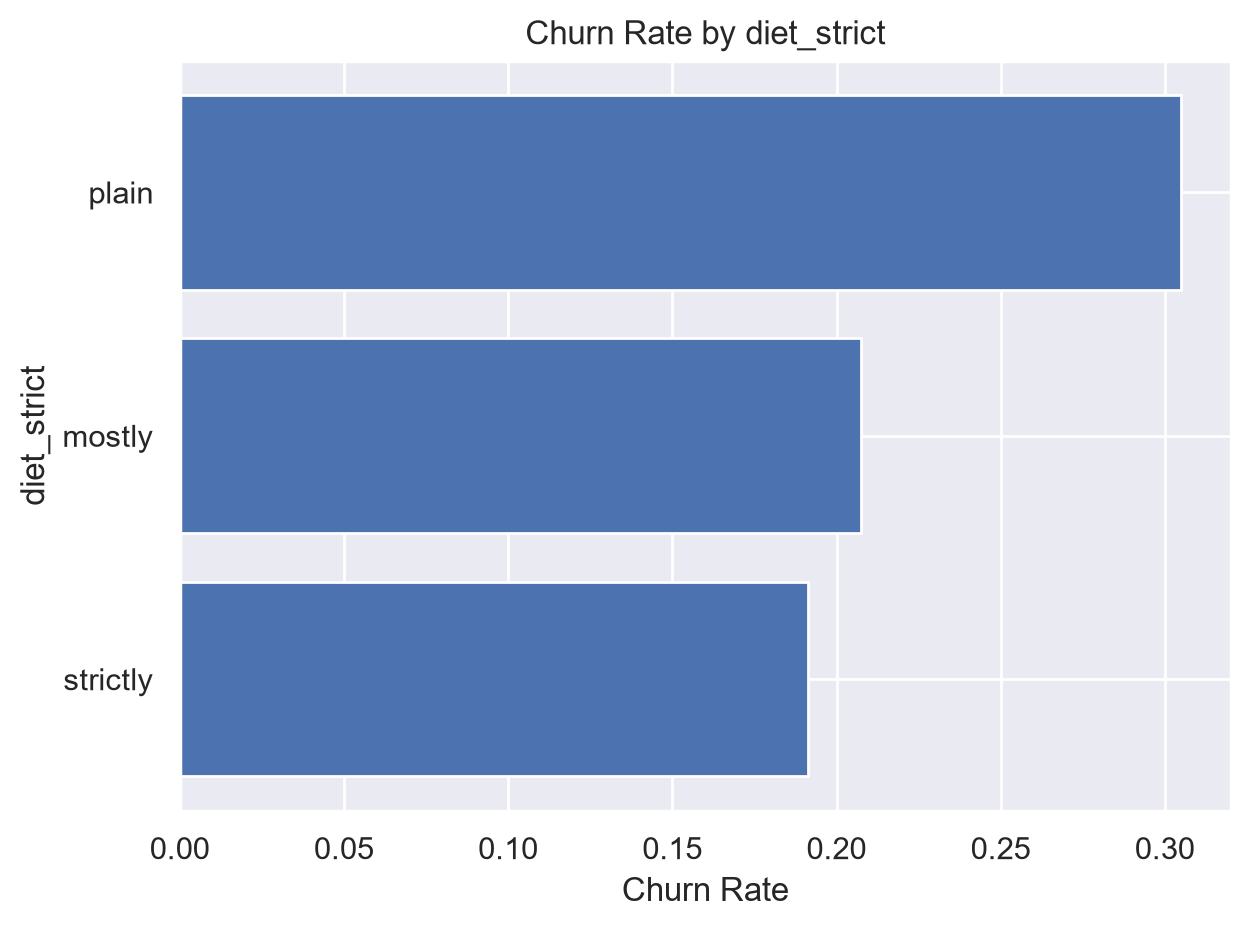

In [28]:
df["diet_strict"] = (
    df["diet"].str.extract(r"^(mostly|strictly)", expand=False)
    .fillna("plain").where(df["diet"].notna())
)
show_hor_bar(df["diet_strict"])

In [29]:
df["diet_strict"].value_counts() / df.shape[0] * 100

diet_strict
plain       52.903757
mostly      35.892702
strictly    11.203541
Name: count, dtype: float64

## drinks (제거한 feature)

In [30]:
df["drinks"].value_counts() / df.shape[0] * 100

drinks
socially         69.714629
rarely            9.960186
often             8.585600
not at all        5.382682
not_disclosed     4.986766
very often        0.787384
desperately       0.582753
Name: count, dtype: float64

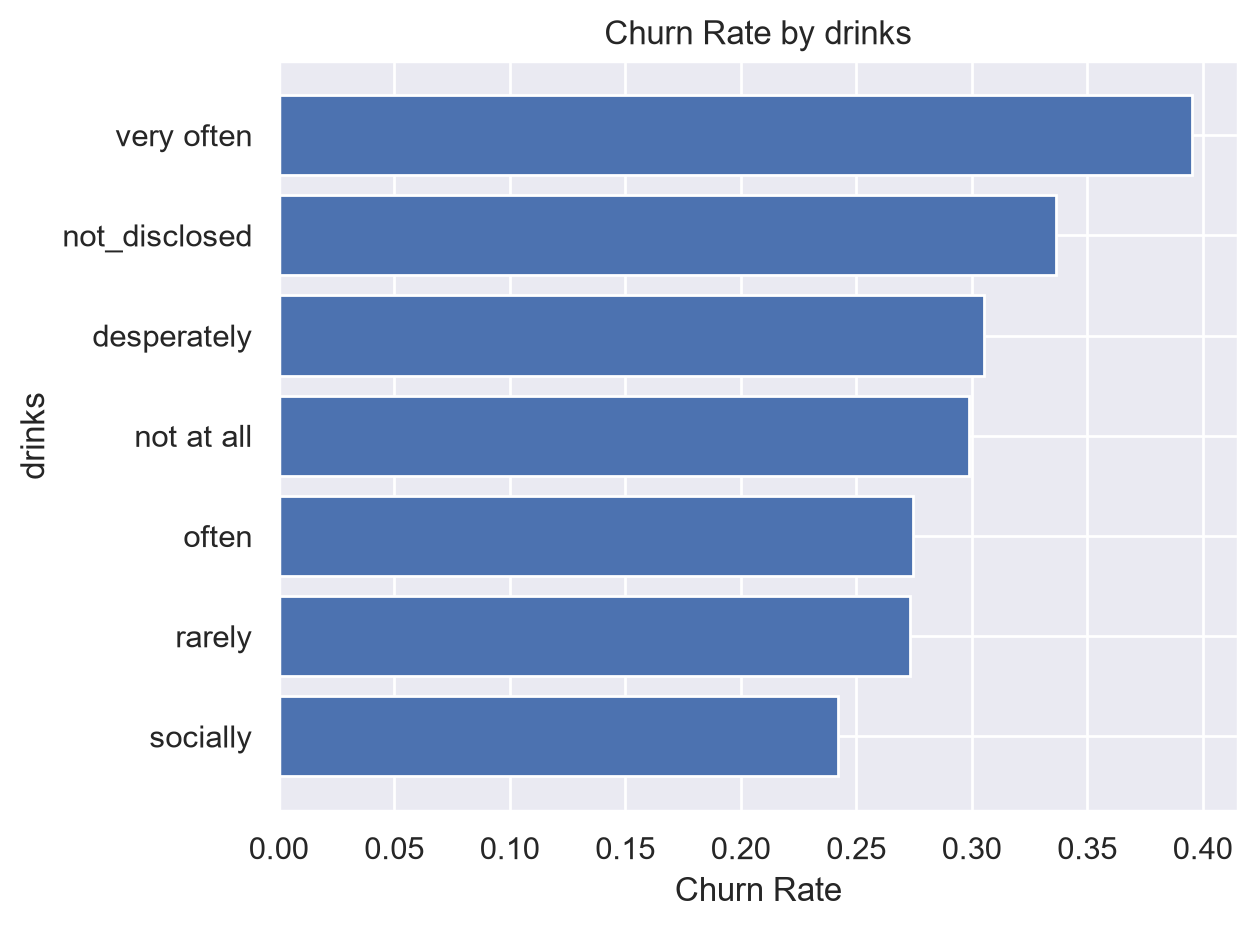

In [31]:
show_hor_bar(df["drinks"])

## drugs

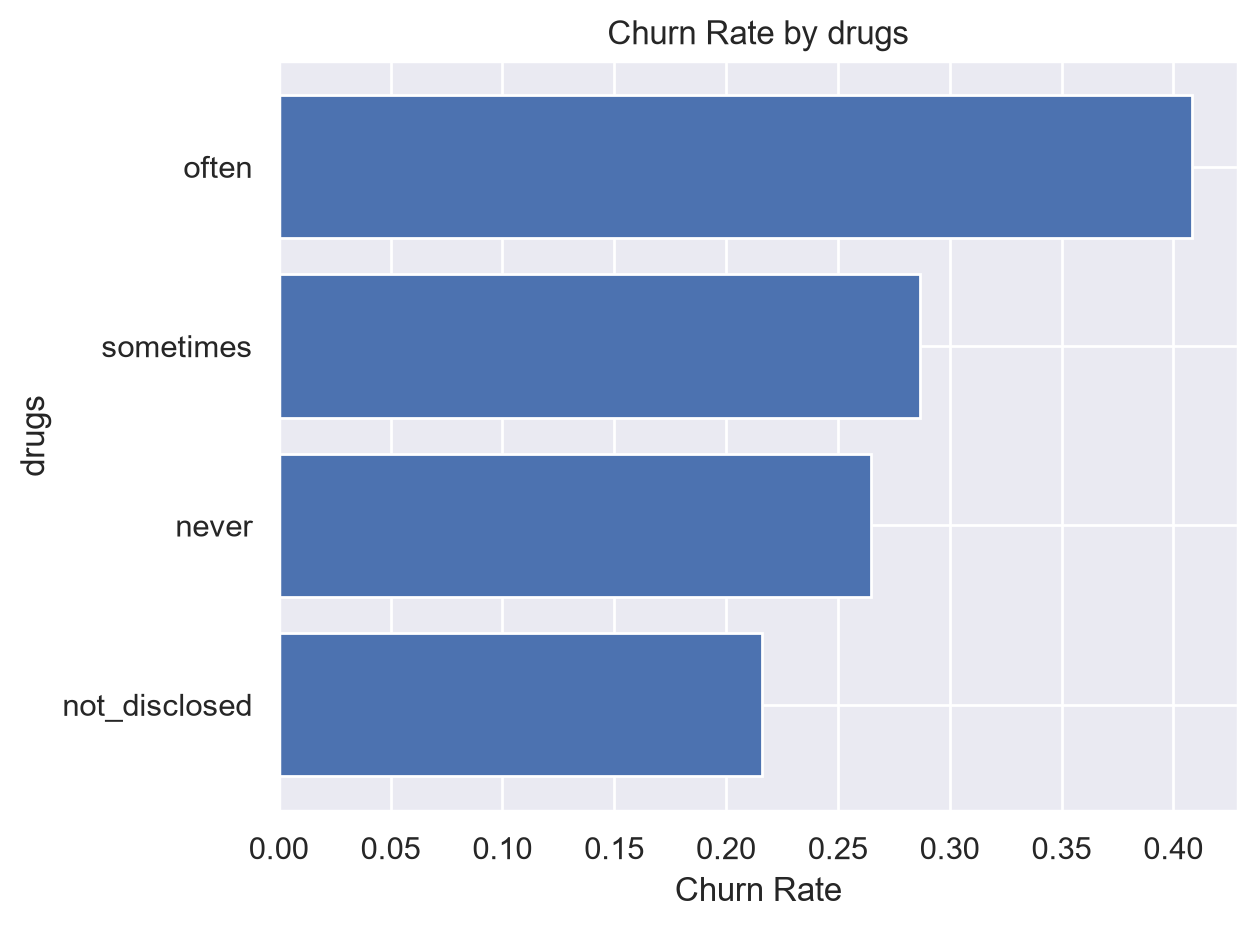

In [32]:
show_hor_bar(df["drugs"])

## smokes

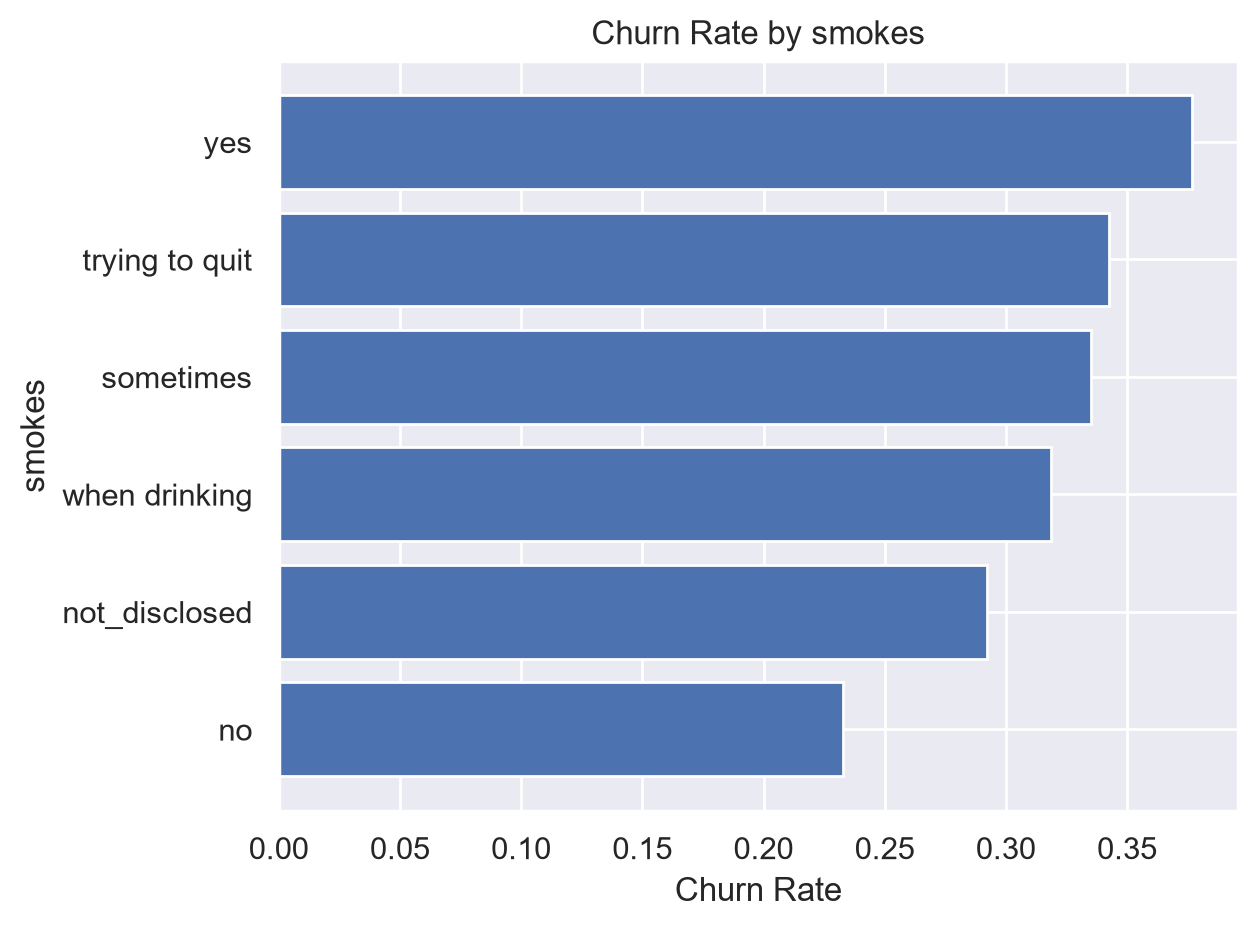

In [33]:
show_hor_bar(df["smokes"])

## education

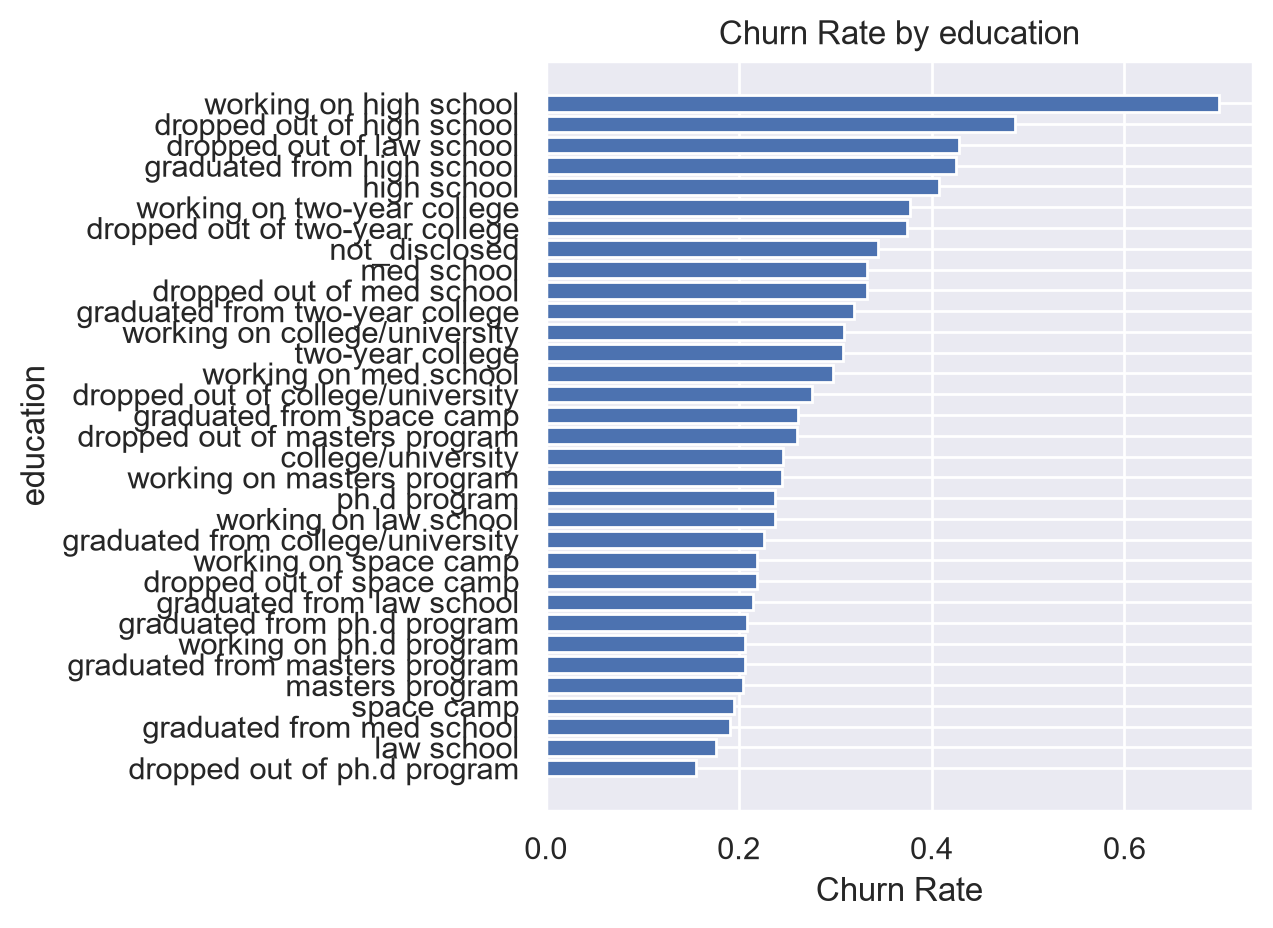

In [34]:
show_hor_bar(df["education"])

### edu_level (교육 유형)

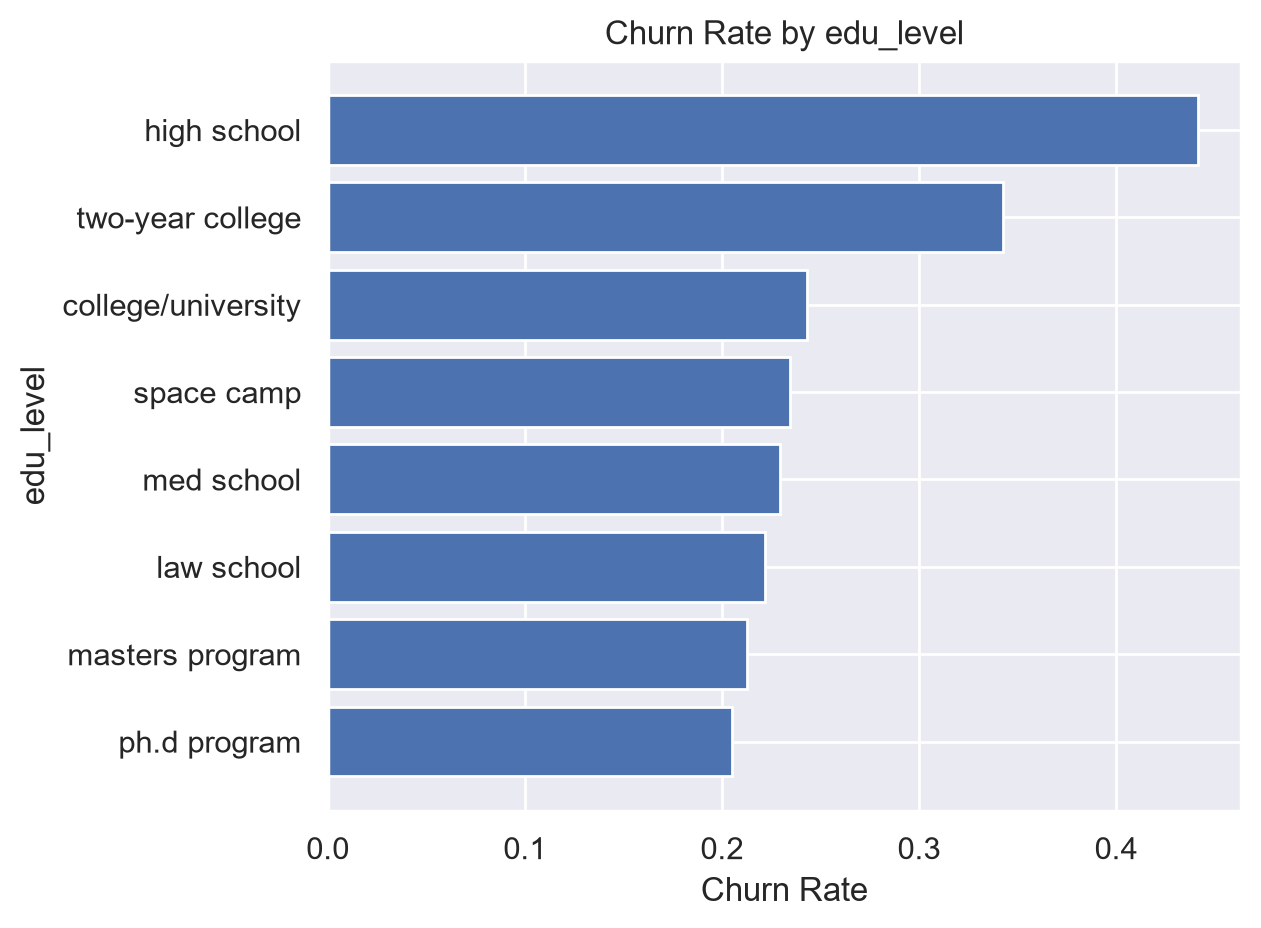

In [35]:
df["edu_level"] = df["education"].str.extract(
    r"(high school|two-year college|college/university|masters program"
    r"|law school|med school|ph\.d program|space camp)", expand=False
)

show_hor_bar(df["edu_level"])

# masters : 석사
# ph.d : 박사

In [36]:
df["edu_level"].value_counts() / df.shape[0] * 100

edu_level
college/university    52.607932
masters program       18.094264
two-year college       5.017905
ph.d program           3.970284
high school            2.822572
space camp             2.804778
law school             2.397740
med school             1.154385
Name: count, dtype: float64

### edu_status (교육 상태)

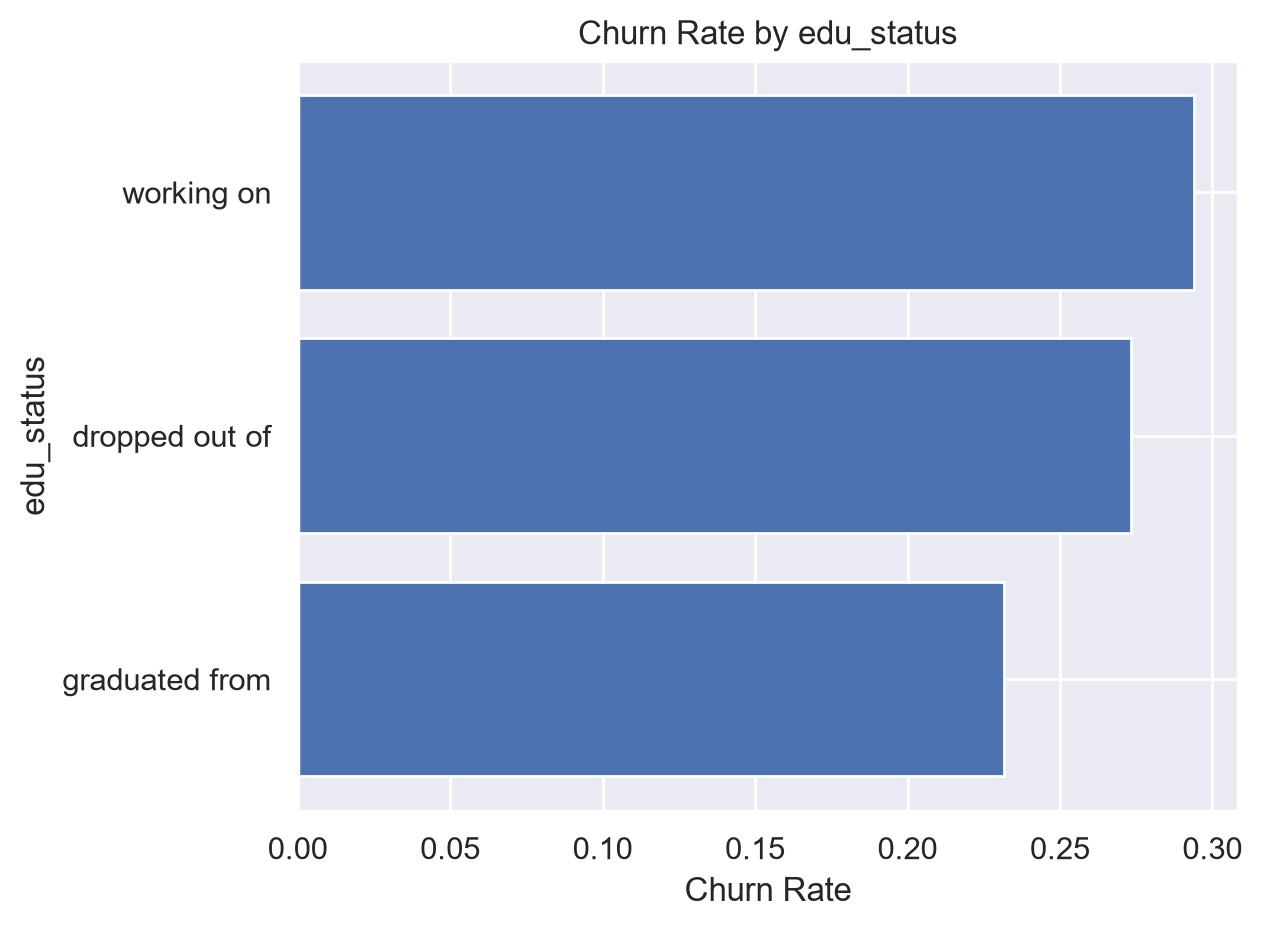

In [37]:
df["edu_status"] = df["education"].str.extract(
    r"^(graduated from|working on|dropped out of)", expand=False)

show_hor_bar(df["edu_status"])

In [38]:
df["edu_status"].value_counts() / df.shape[0] * 100

edu_status
graduated from    65.659823
working on        17.389177
dropped out of     3.556574
Name: count, dtype: float64

## ethnicity (제거한 feature)

C:\Users\iyuri\AppData\Local\Temp\ipykernel_4148\4113490862.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


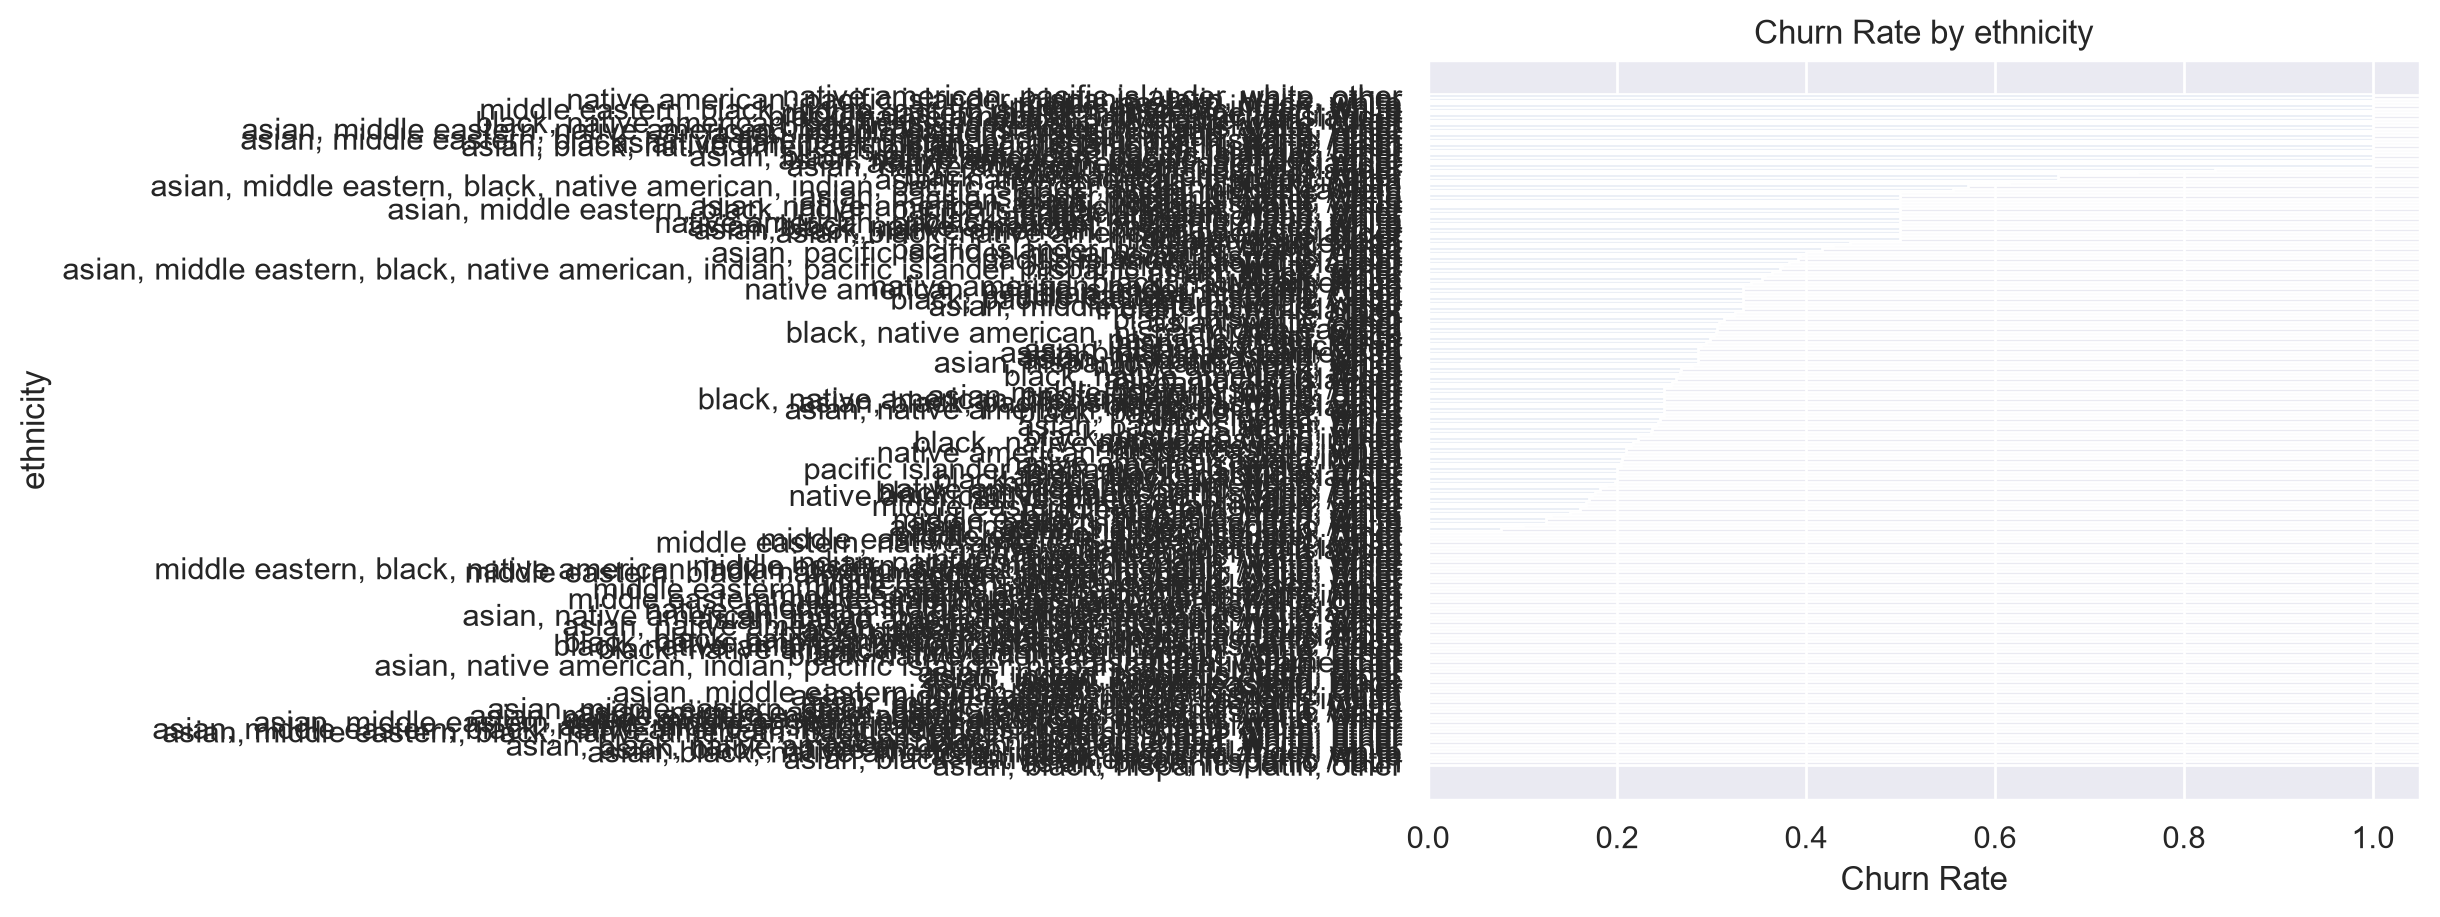

In [39]:
show_hor_bar(df["ethnicity"])

In [40]:
df["ethnicity"].nunique()

202

## income

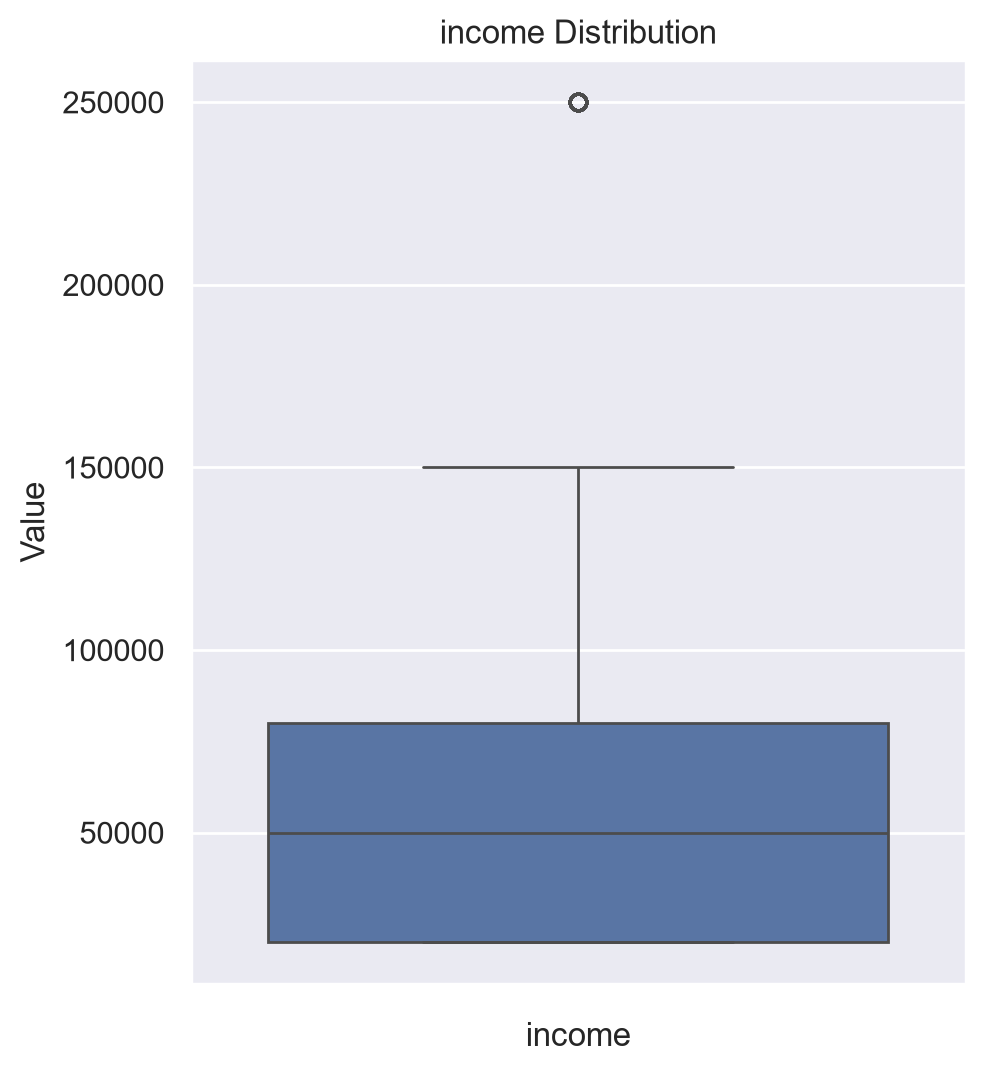

In [41]:
show_box(df.loc[df["income"].between(0, 300000), "income"])

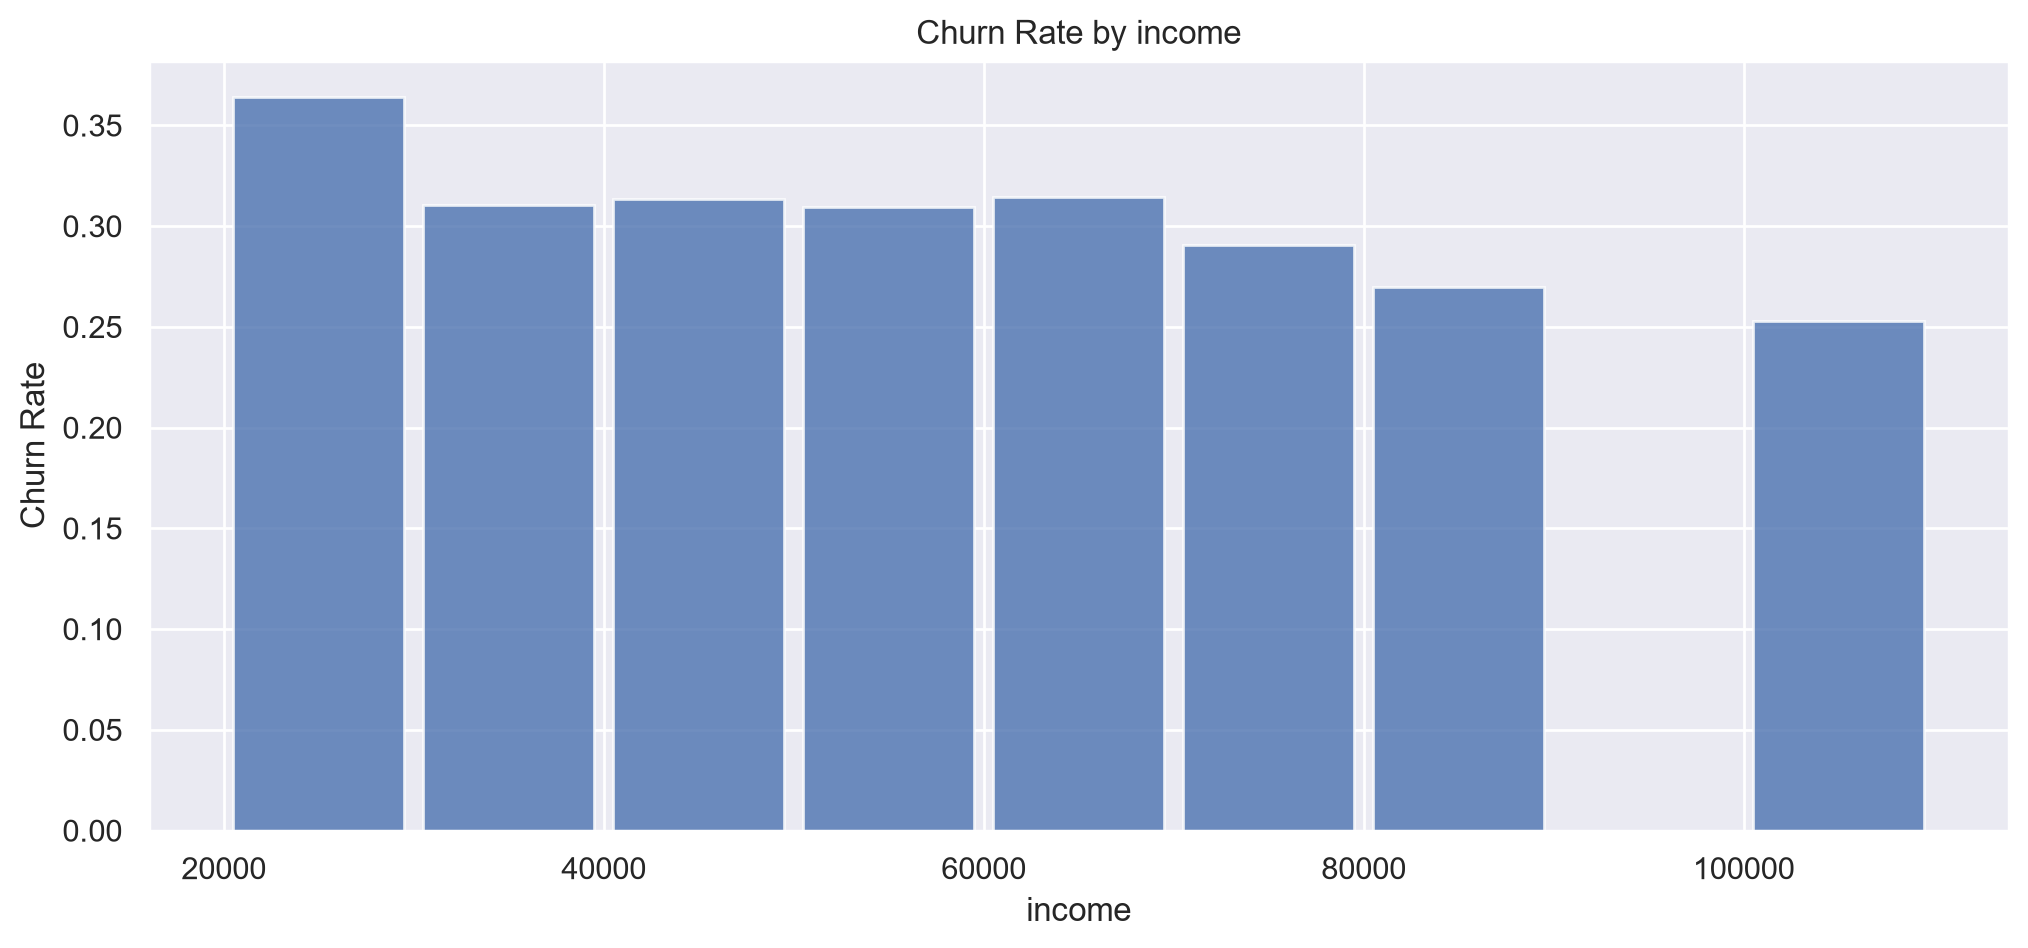

In [68]:
# 5살 단위로 나이 구간 생성
income_bins = pd.cut(
    df["income"],
    bins=range(20000, 150000, 10000),
    right=False
)

show_hist(income_bins)

## job

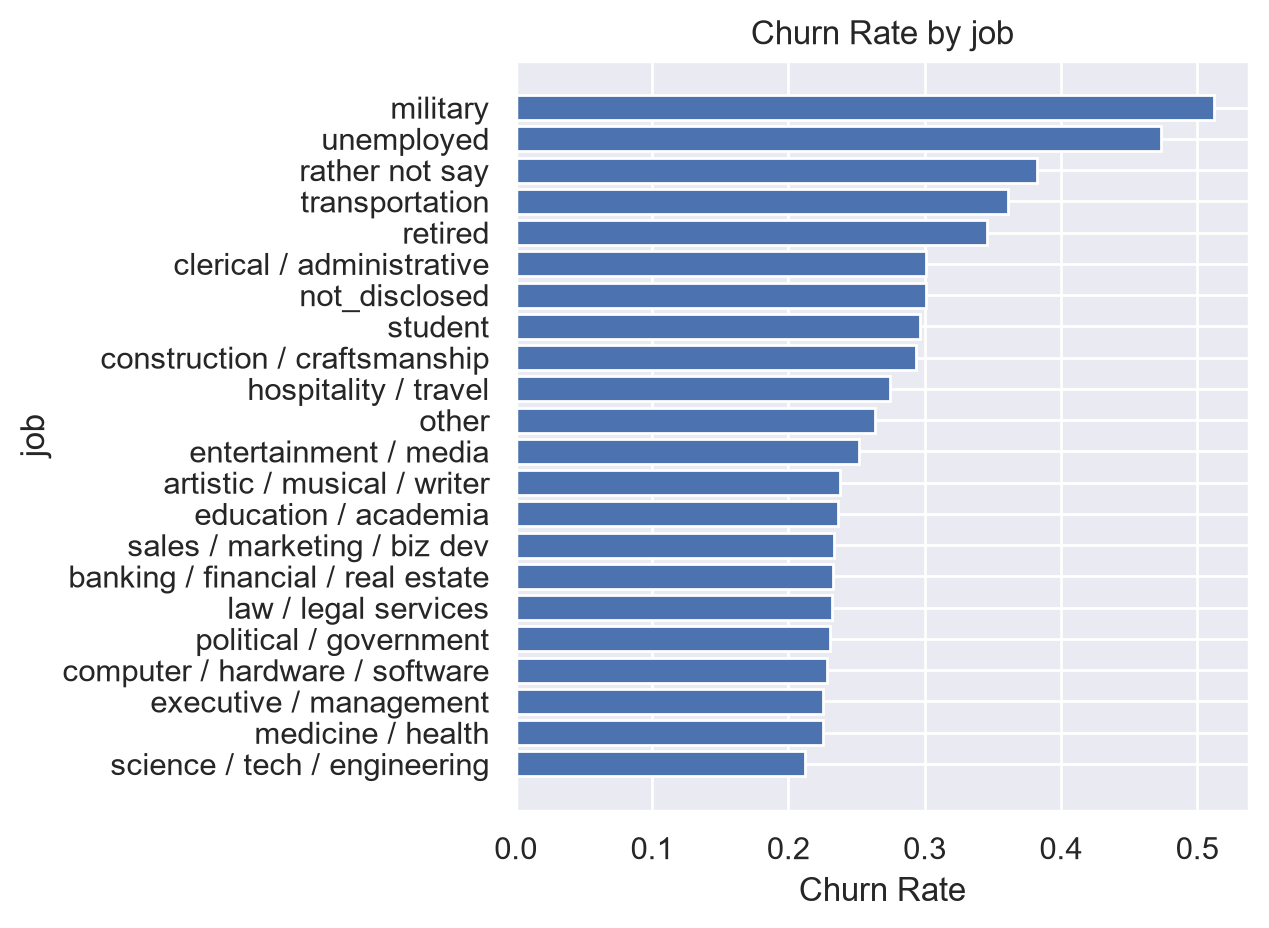

In [43]:
show_hor_bar(df["job"])

## offspring (자녀 유무, 계획)

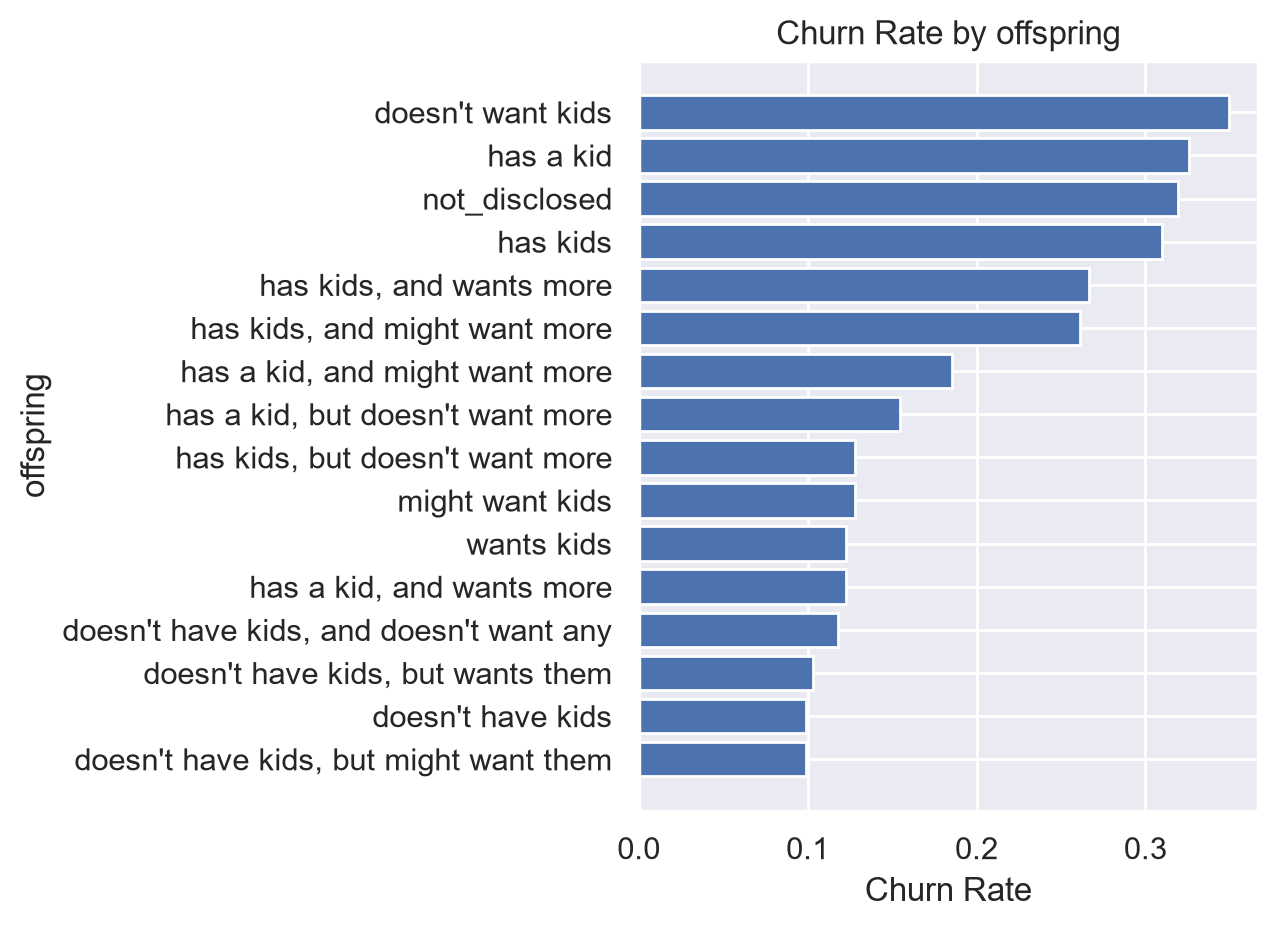

In [44]:
show_hor_bar(df["offspring"])

### has_kids

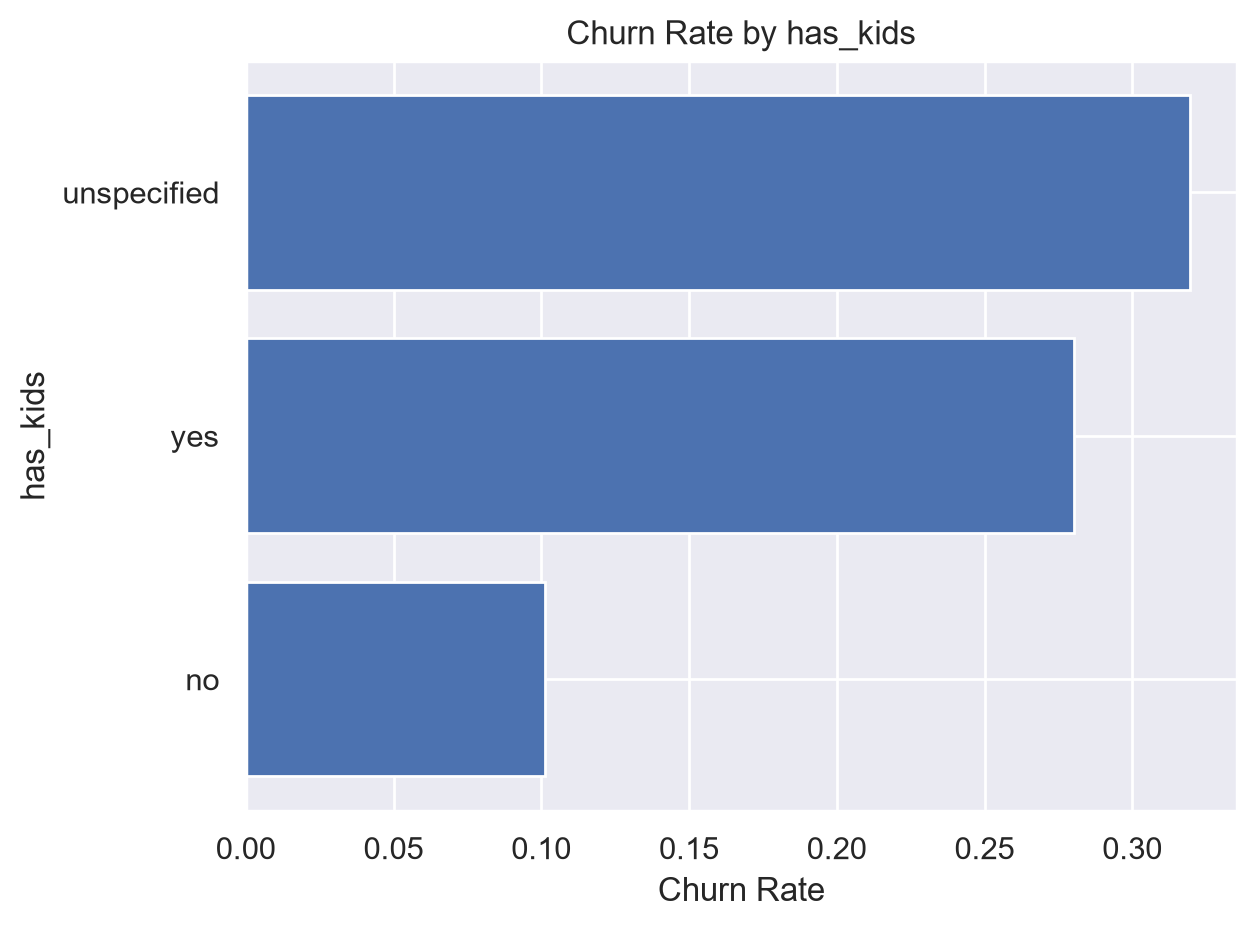

In [ ]:
df["has_kids"] = (
    df["offspring"].str.extract(r"^(has|doesn't have kids)", expand=False)
    .map({"has": "yes", "doesn't have kids": "no"})
)

df["has_kids"] = df["has_kids"].fillna("unspecified").where(df["offspring"].notna())

show_hor_bar(df["has_kids"])

In [46]:
df["has_kids"].value_counts() / df.shape[0] * 100

has_kids
no     27.044641
yes     8.274205
Name: count, dtype: float64

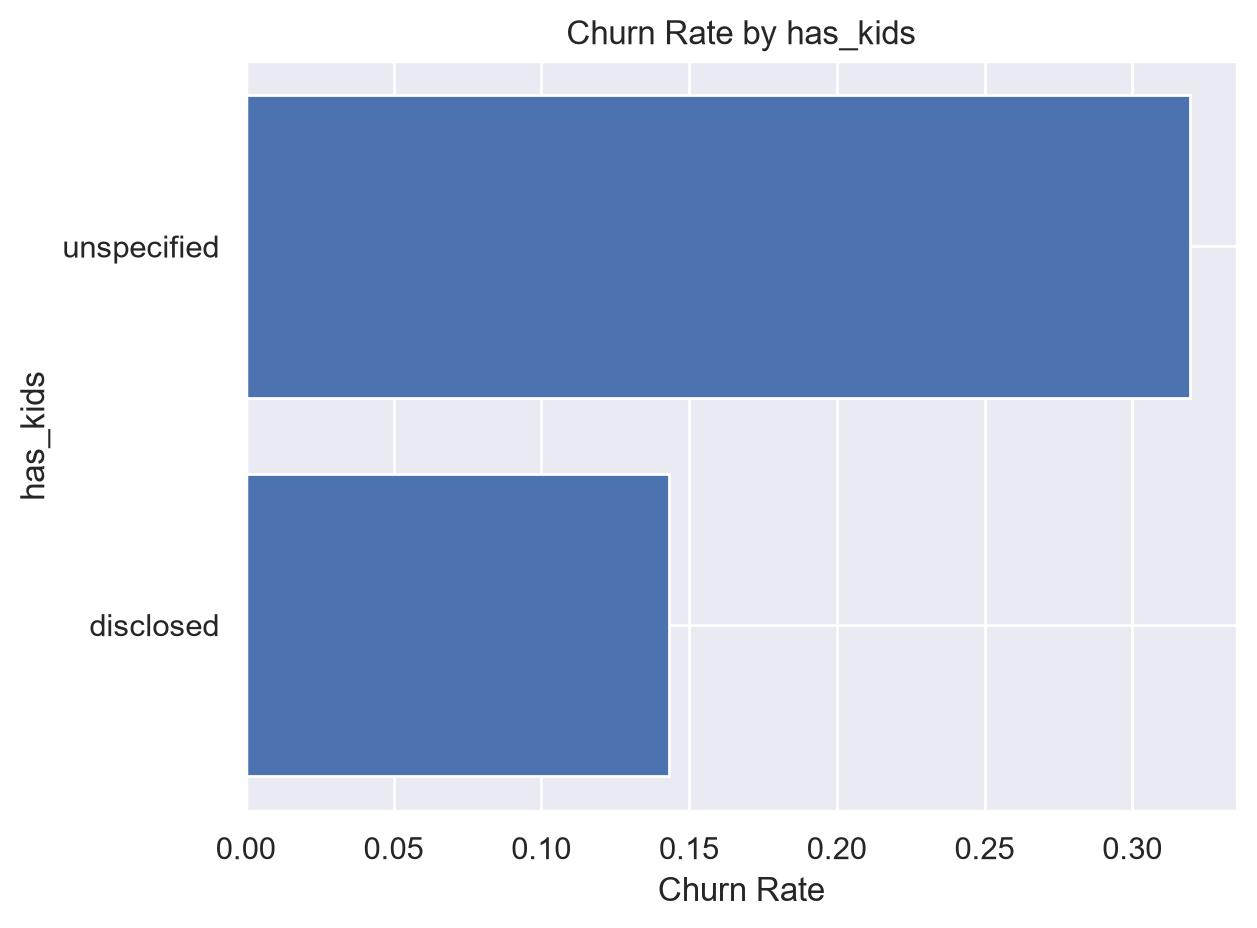

In [75]:
has_kids_group = df["has_kids"].replace({
    "yes": "disclosed",
    "no": "disclosed"
})

has_kids_group.value_counts()

show_hor_bar(has_kids_group)

### wants_kids

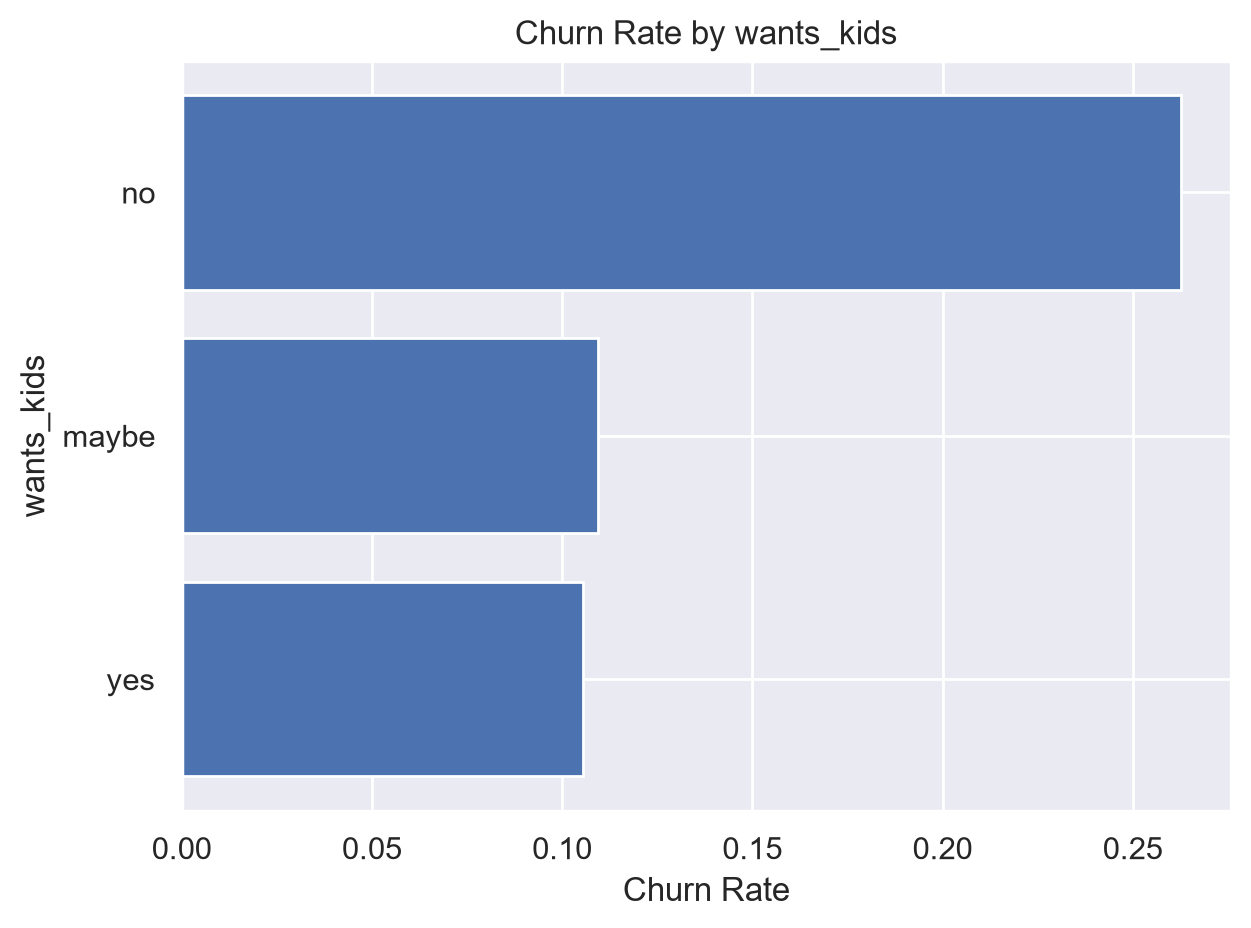

In [47]:
df["wants_kids"] = (
    df["offspring"].str.extract(r"(might want|doesn't want|wants)", expand=False)
    .map({"might want": "maybe", "doesn't want": "no", "wants": "yes"})
)

show_hor_bar(df["wants_kids"])

In [48]:
df["wants_kids"].value_counts() / df.shape[0] * 100

wants_kids
no       7.933895
maybe    7.337797
yes      6.532619
Name: count, dtype: float64

## pets (제거한 feature)

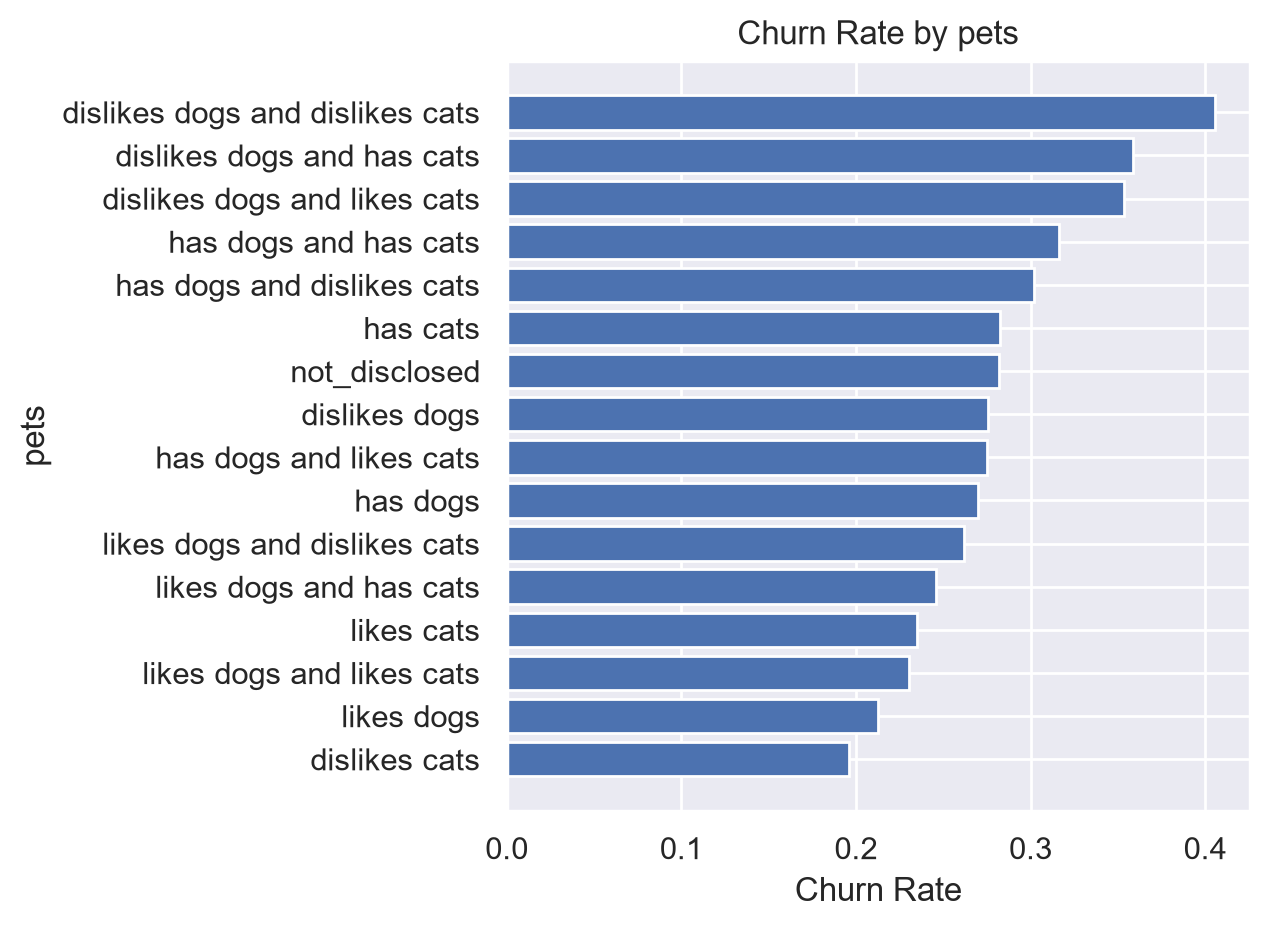

In [49]:
show_hor_bar(df["pets"])

In [50]:
(df["pets"].value_counts() / df.shape[0] * 100).head(10)

pets
not_disclosed                   33.212482
likes dogs and likes cats       24.689161
likes dogs                      12.086568
likes dogs and has cats          7.173202
has dogs                         6.961899
has dogs and likes cats          3.887987
likes dogs and dislikes cats     3.432016
has dogs and has cats            2.475589
has cats                         2.337685
likes cats                       1.692653
Name: count, dtype: float64

## religion_type

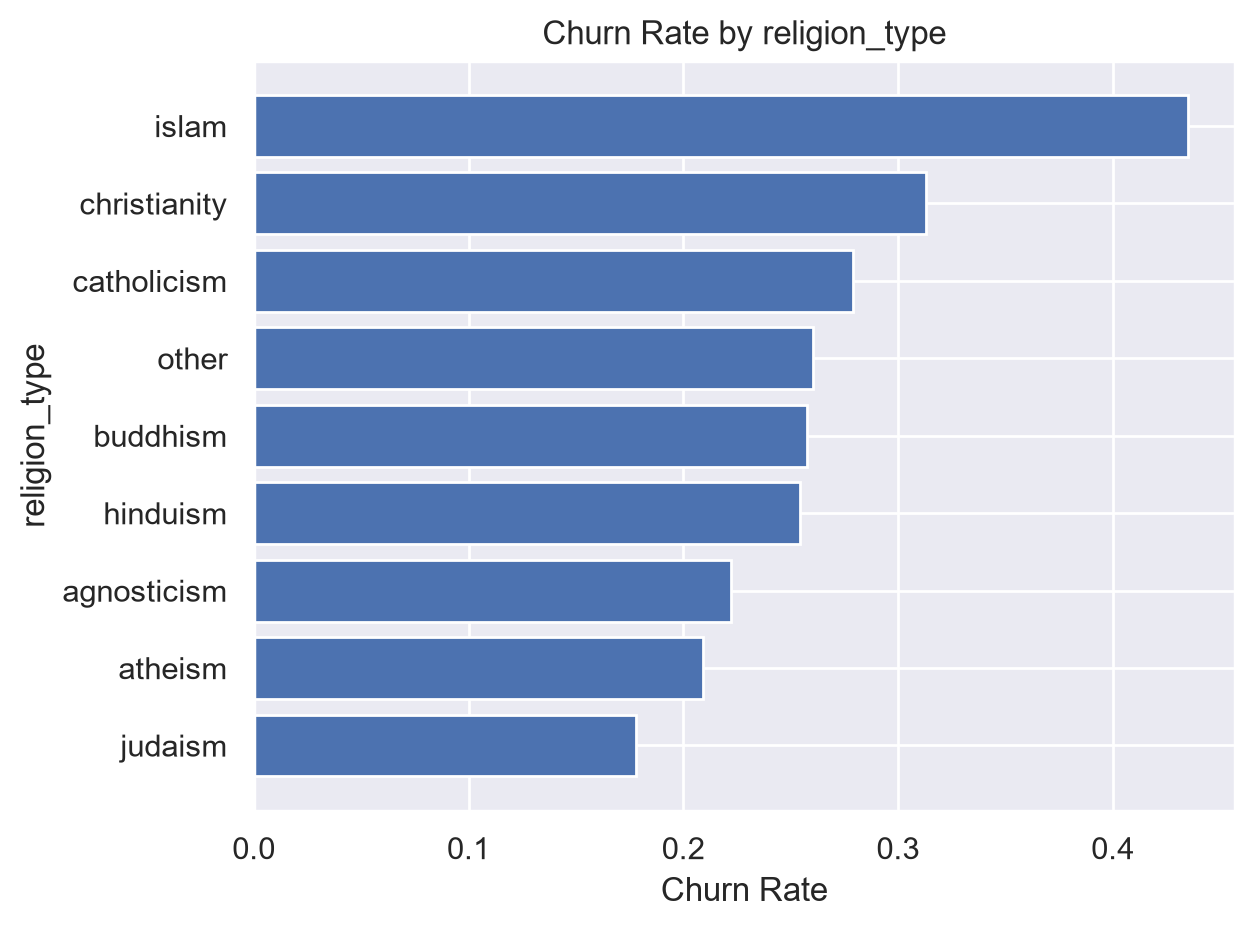

In [51]:
df["religion_type"] = df["religion"].str.extract(
    r"^(agnosticism|atheism|christianity|judaism|catholicism"
    r"|islam|hinduism|buddhism|other)", expand=False)

show_hor_bar(df["religion_type"])

# agnosticism, athesism : 신의 존재를 덜 믿음
# judaism : 유대교

In [52]:
df["religion_type"].value_counts() / df.shape[0] * 100

religion_type
agnosticism     14.562157
other           12.733824
atheism         11.821882
christianity     9.651015
catholicism      7.965035
judaism          5.166930
buddhism         3.265197
hinduism         0.769590
islam            0.240219
Name: count, dtype: float64

## zodiac (별자리, 제거한 feature)

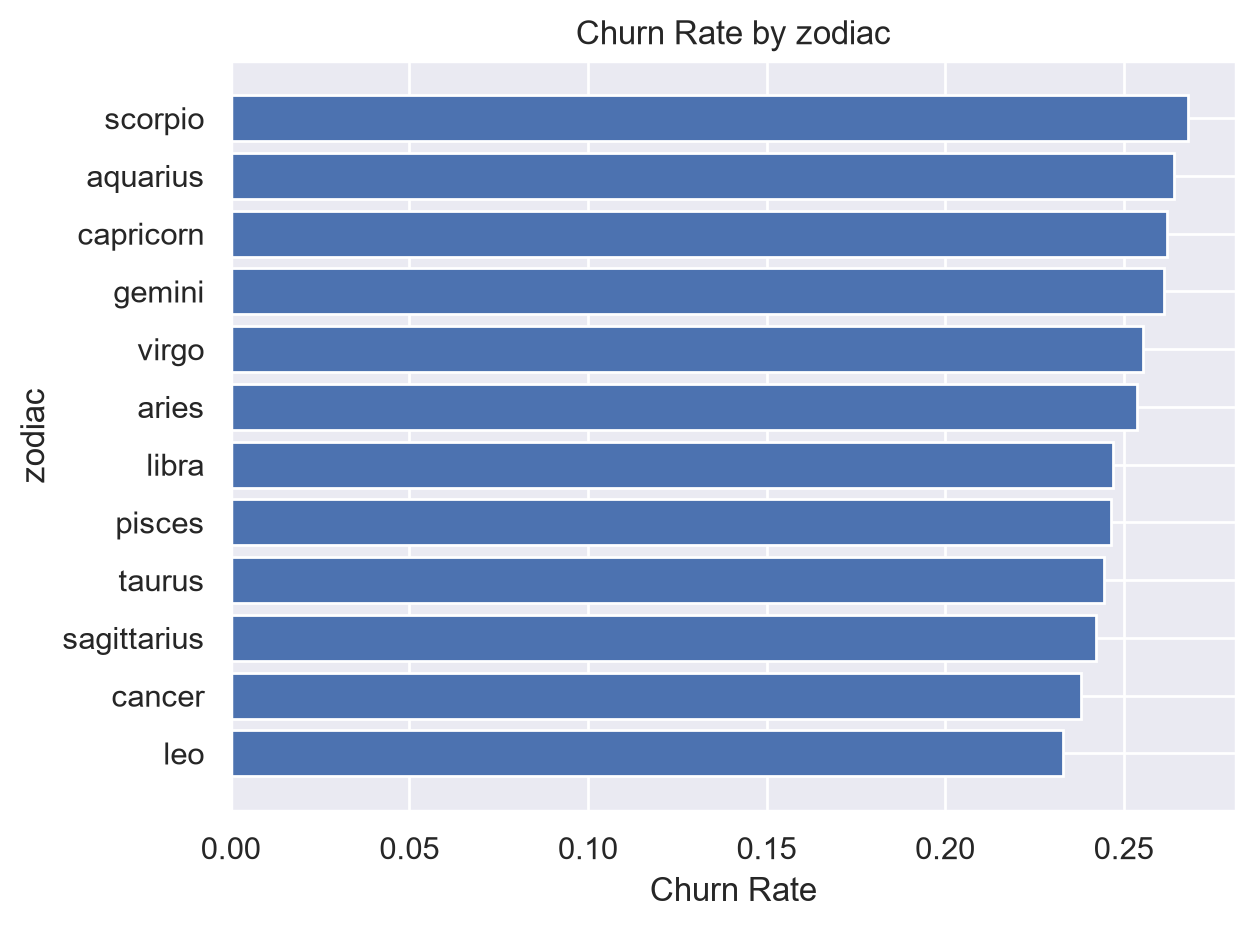

In [53]:
df["zodiac"] = df["sign"].str.extract(
    r"^(aries|taurus|gemini|cancer|leo|virgo|libra|scorpio|sagittarius|capricorn|aquarius|pisces)\b",
    expand=False
)

show_hor_bar(df["zodiac"])

## essay

In [54]:
df[ESSAY].describe()

,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
count,40844,39249,37718,36349,37021,36794,34555,35612,30516,35468
unique,40769,38654,36557,32848,36928,36705,32772,34250,29581,34136
top,.,enjoying it.,listening,my smile,ask me,my family,my future,out with friends,ask me,you want to.
freq,10,44,61,385,12,5,116,69,36,149


In [55]:
df[ESSAY].head()

,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
52240,"love running, motorcycles, cars and aerospace....","work, school and some fun!",making things happen,smile!,NaN,NaN,how to make the world a better place for all o...,NaN,i chew my nails. gross!! i know,NaN
30039,"i'm a born and raised california girl, sun-kis...",ugh this is a tough question. i just graduated...,i think i am really good at caring for other p...,that i am skinny. i get tons of guys who try t...,"books: omnivore's dilemma, the new new thing, ...",1. my computer!! endless entertainment 2. my b...,what and who i want to be in the future,"well at the risk of sounding lame, i usually t...",hmm.. why the hell not! [redacted],you think we'd have fun together and might be ...
52139,"burner, dancer, actor. easy to make blush and ...","psychology, bartending, theatre, love. update...",finding the lesson in any situation and the em...,i'm tall.,"books: care for the soul, when things fall apa...",1. love 2. community 3. music 4. pushing bound...,the definition and power of love; where integr...,"seeing a show, at my sewing table, having an i...",i'm a pretty open hearted and compassionate pe...,...you value integrity and communication. ...y...
46257,i'm an optimist who enjoys listening to npr an...,"shaking down little old ladies for donations, ...",packing picnics making people comfortable baki...,people tend to notice my smile and then my ove...,food: i can throw down in the kitchen. wearing...,1) the internet 2) my friends 3) ricanelas ice...,NaN,out and about with friends sipping cocktails a...,NaN,you're looking for a companion to explore a mu...
24919,i am the type of person who likes to contrast ...,long term: doing that fun college thing. short...,NaN,"people usually notice my height. 6'2"" is not o...","books: lolita, starship troopers, hitchhikers'...",a watch running internet water bottle goofines...,how to fill this about me section in the best ...,going wherever the winds take me.,i'm really into lucid dreaming. i think it is ...,you find beauty in the fact that out of billio...


### essay_count

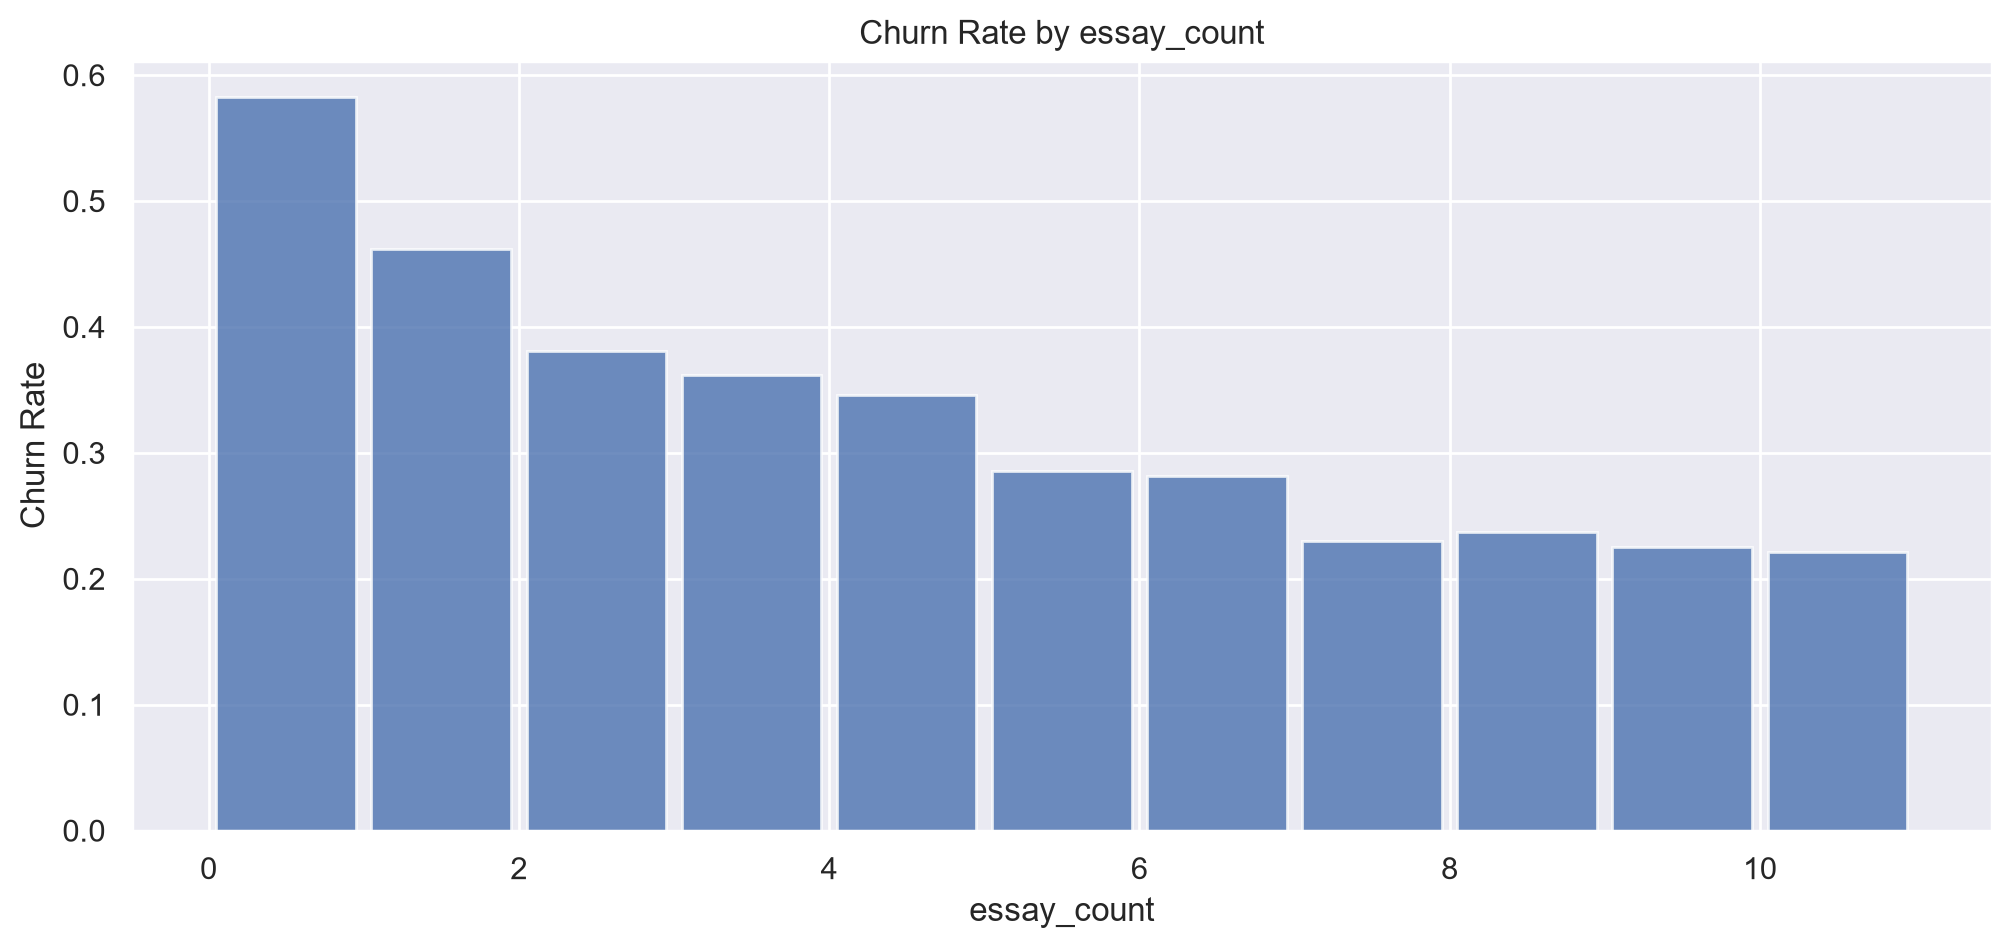

In [56]:
df["essay_count"] = df[ESSAY].notna().sum(axis=1)
essay_count_bins = pd.cut(
    df["essay_count"],
    bins=range(0, 12),
    right=False
)

show_hist(essay_count_bins)

### essay_total_words

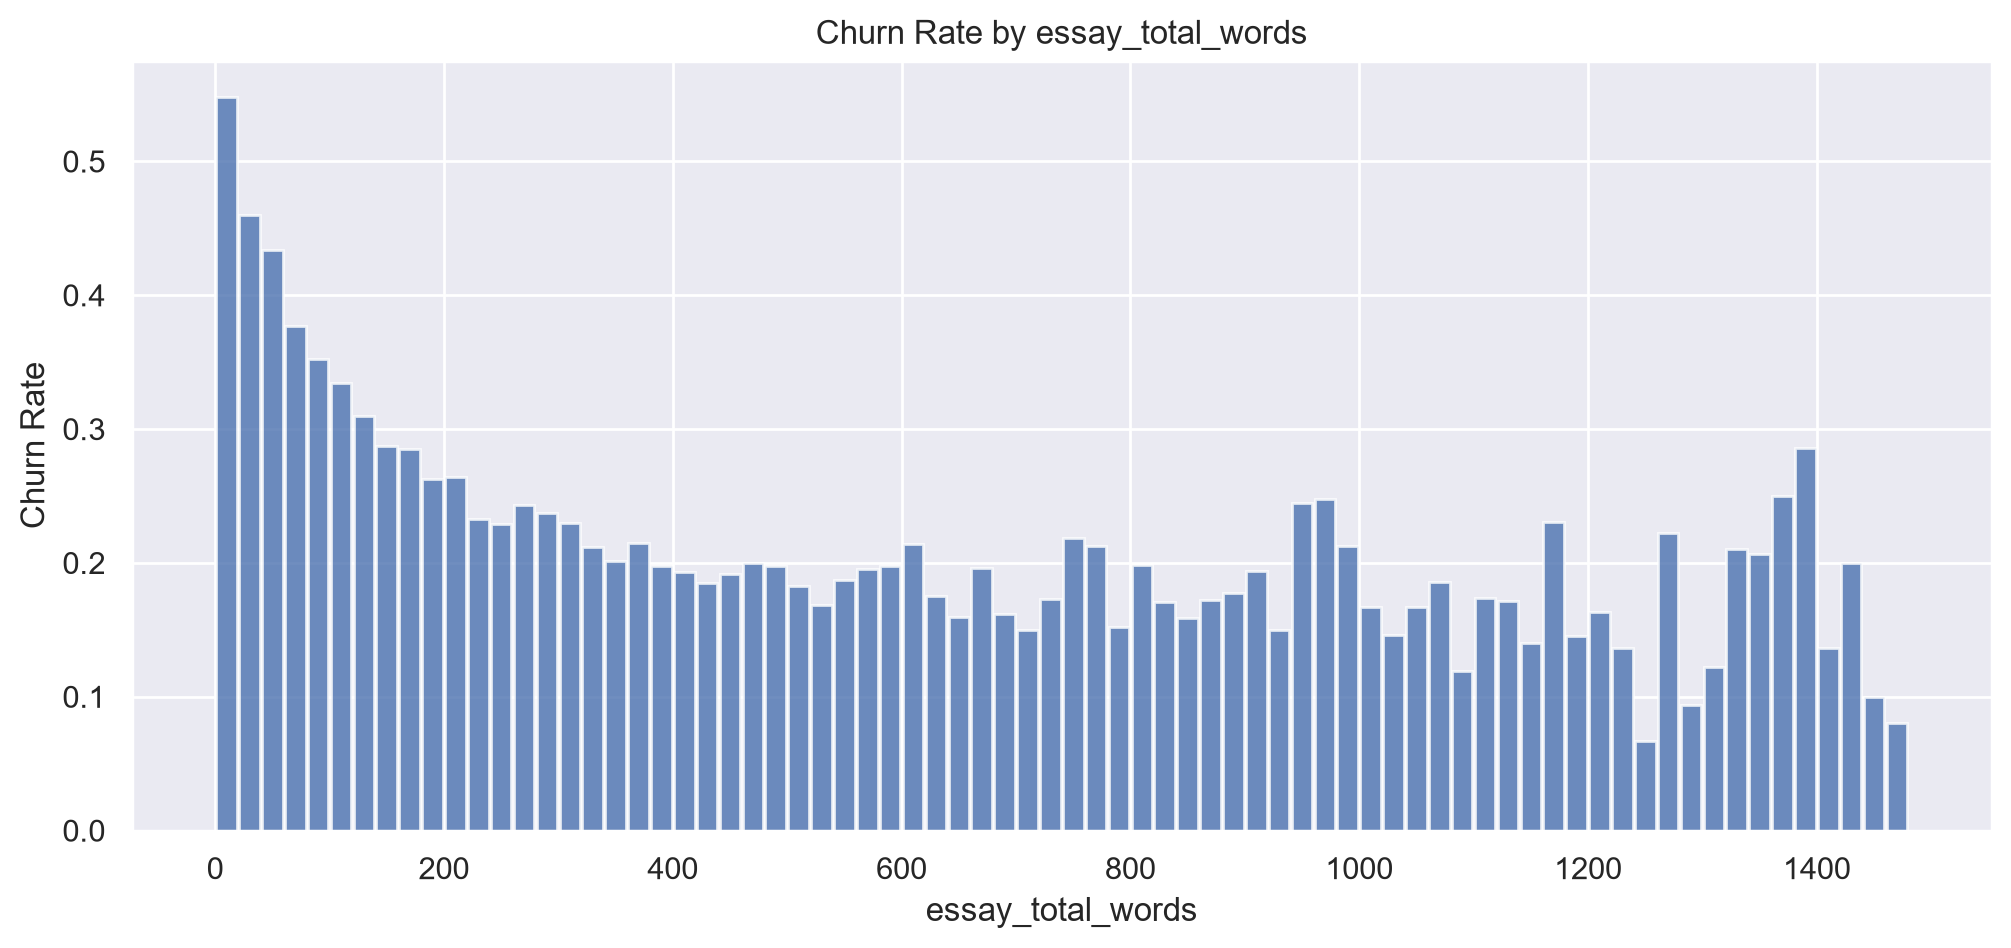

In [57]:
clean = df[ESSAY].apply(
    lambda col: col.str.replace(r"(?:<[^>]+>|\s)+", " ", regex=True).str.strip())
df["essay_total_words"] = clean.apply(lambda col: col.str.count(r"\b\w+\b")).sum(axis=1)

essay_words_bins = pd.cut(
    df["essay_total_words"],
    bins=range(0, 1500, 20),
    right=False
)
show_hist(essay_words_bins)

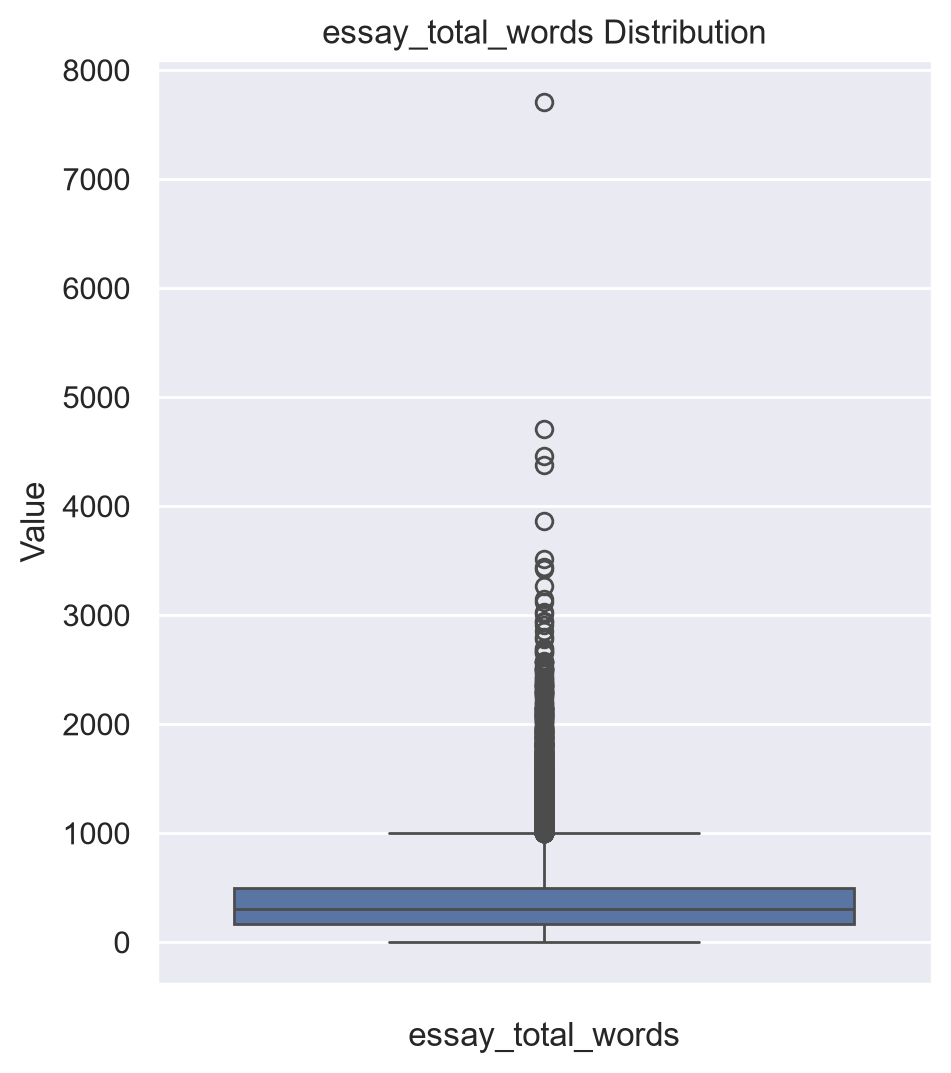

In [58]:
show_box(df["essay_total_words"])

### essay_avg_len

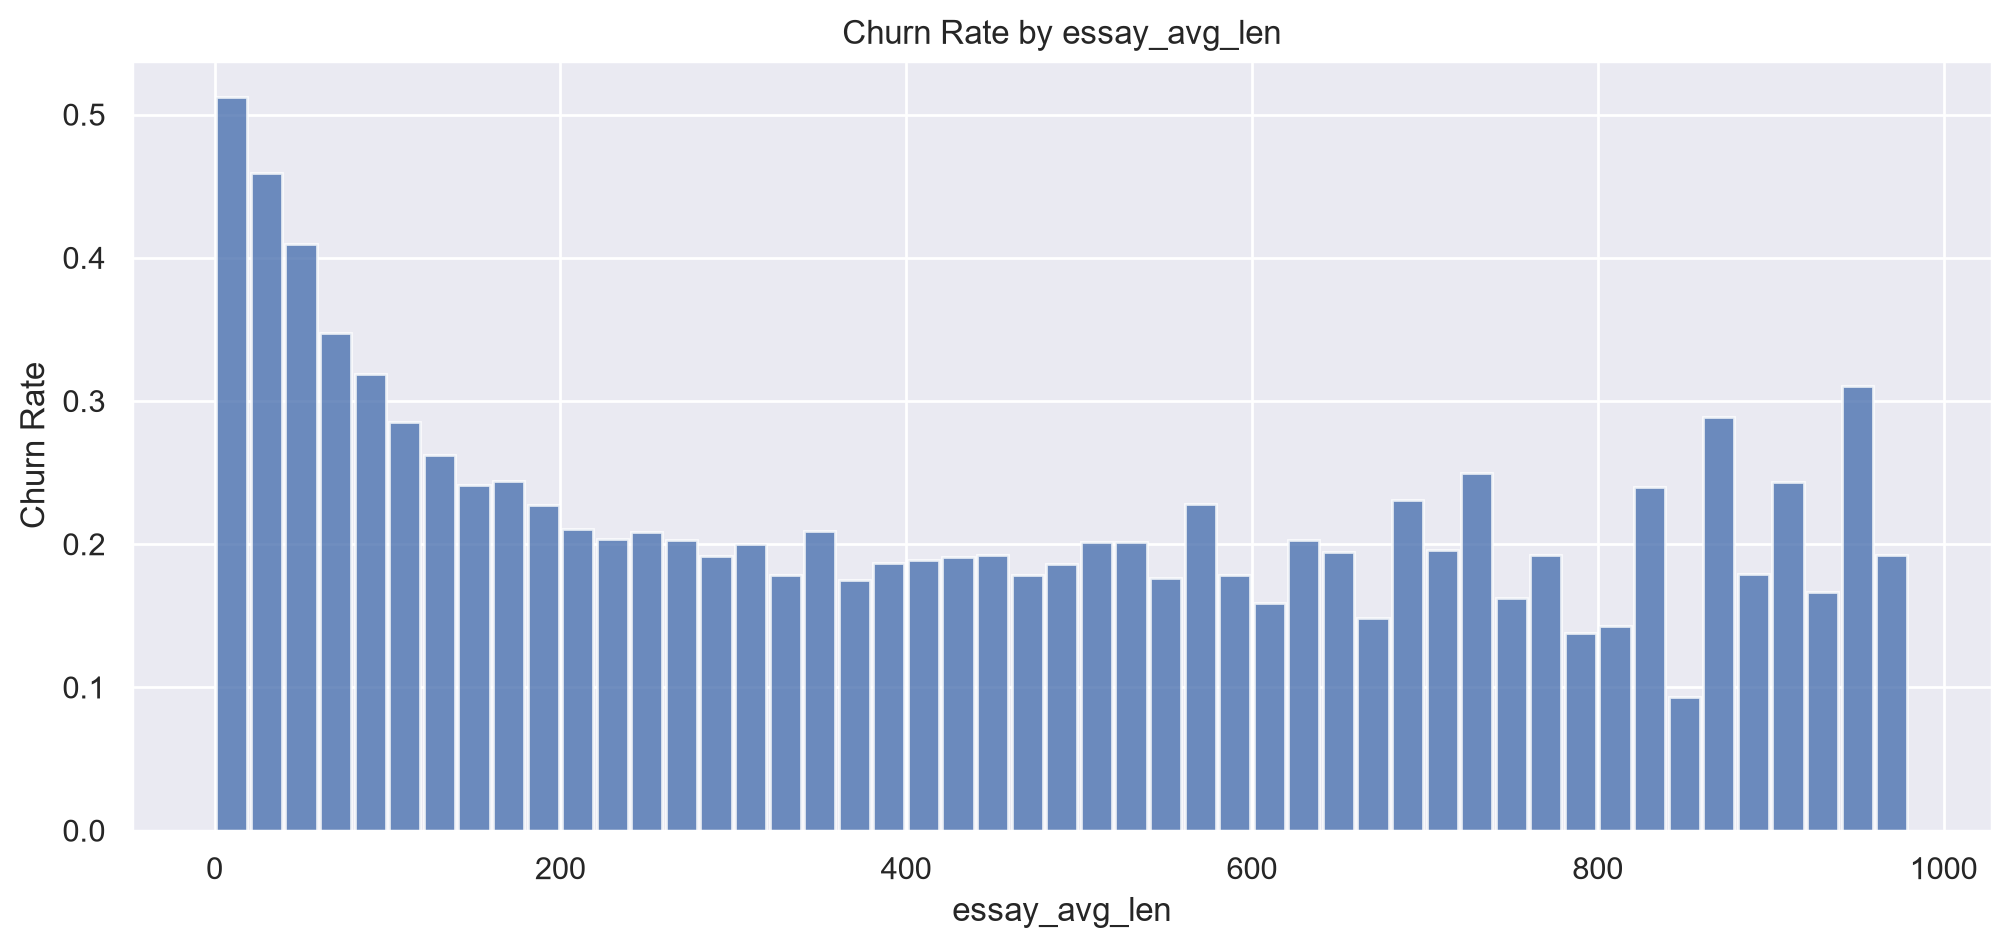

In [59]:
lengths = clean.apply(lambda col: col.str.len()).where(df[ESSAY].notna())
df["essay_avg_len"] = lengths.mean(axis=1)

essay_avg_len_bins = pd.cut(
    df["essay_avg_len"],
    bins=range(0, 1000, 20),
    right=False
)
show_hist(essay_avg_len_bins)

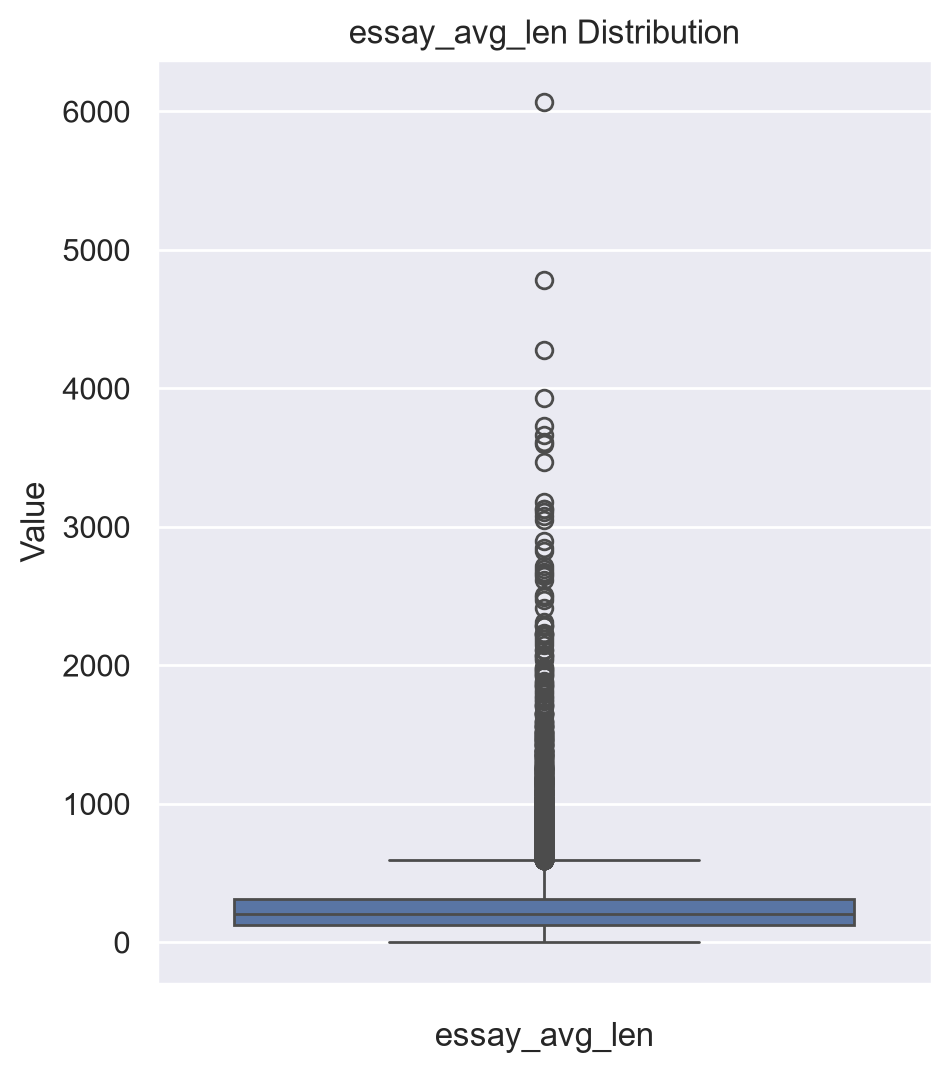

In [60]:
show_box(df["essay_avg_len"])

### essay_len_std

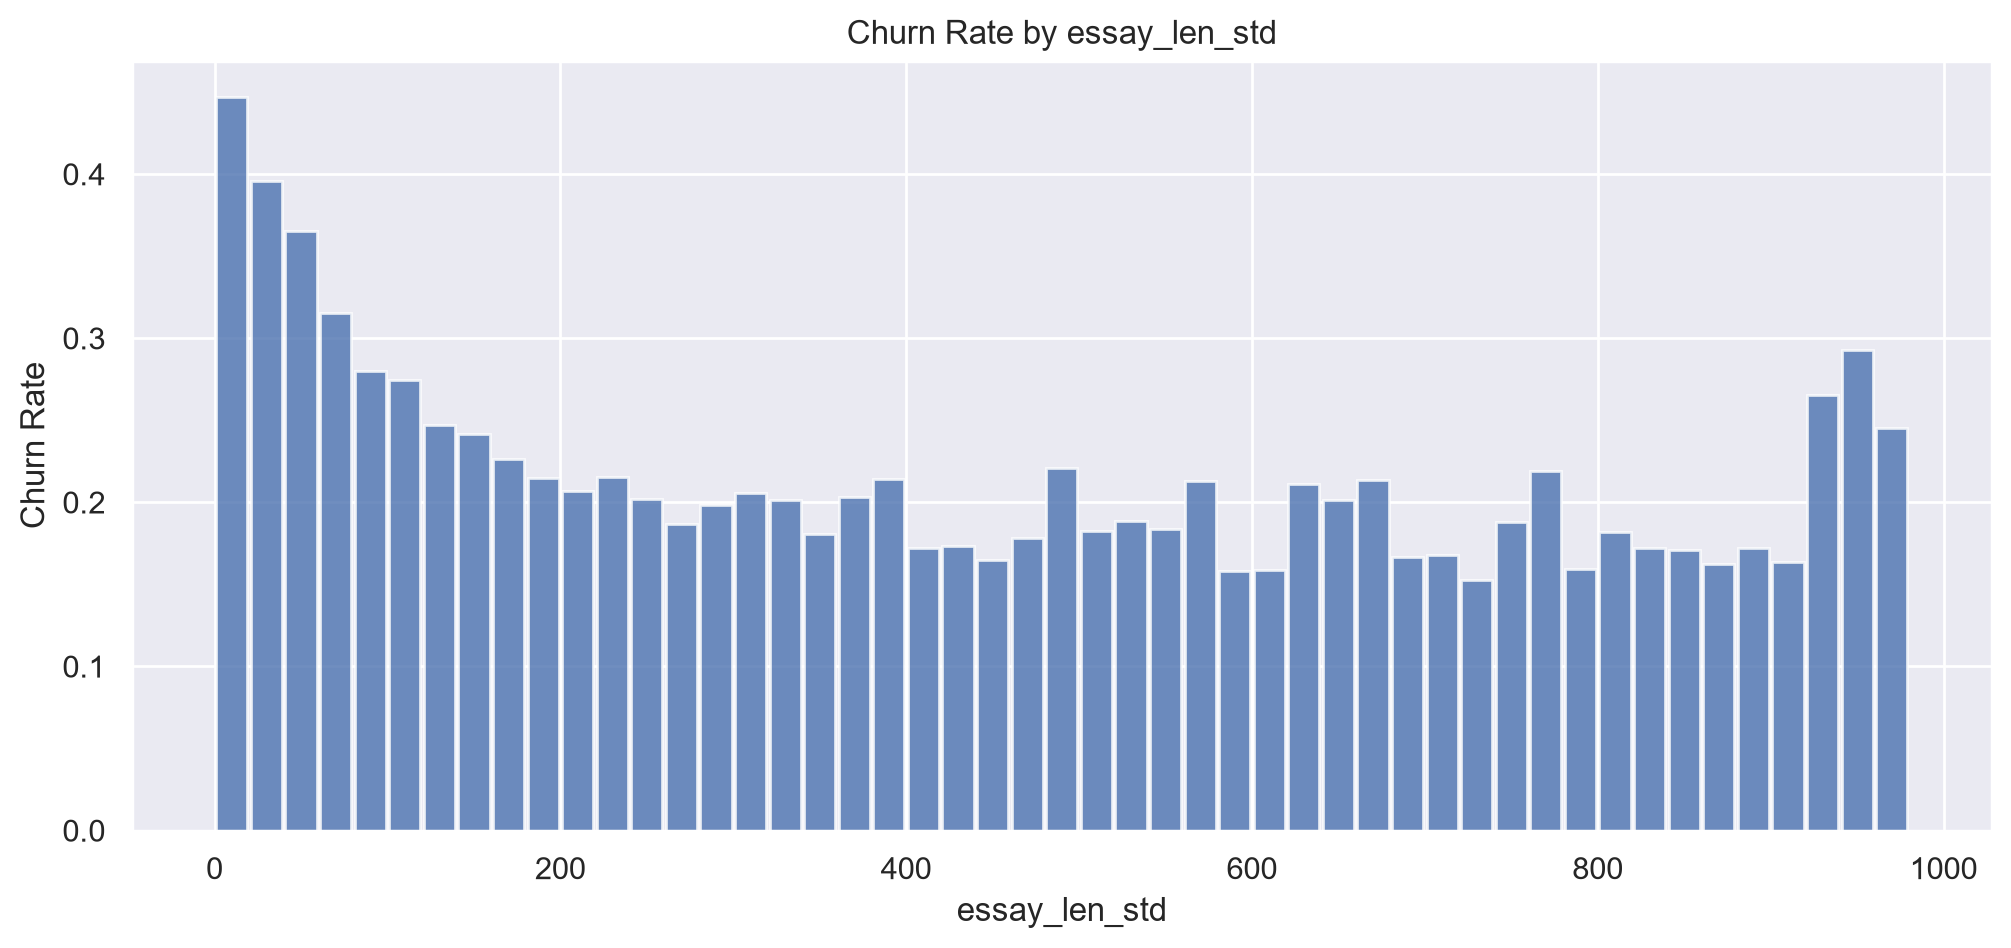

In [61]:
df["essay_len_std"] = lengths.std(axis=1)

essay_len_std_bins = pd.cut(
    df["essay_len_std"],
    bins=range(0, 1000, 20),
    right=False
)
show_hist(essay_len_std_bins)

## profile_completeness

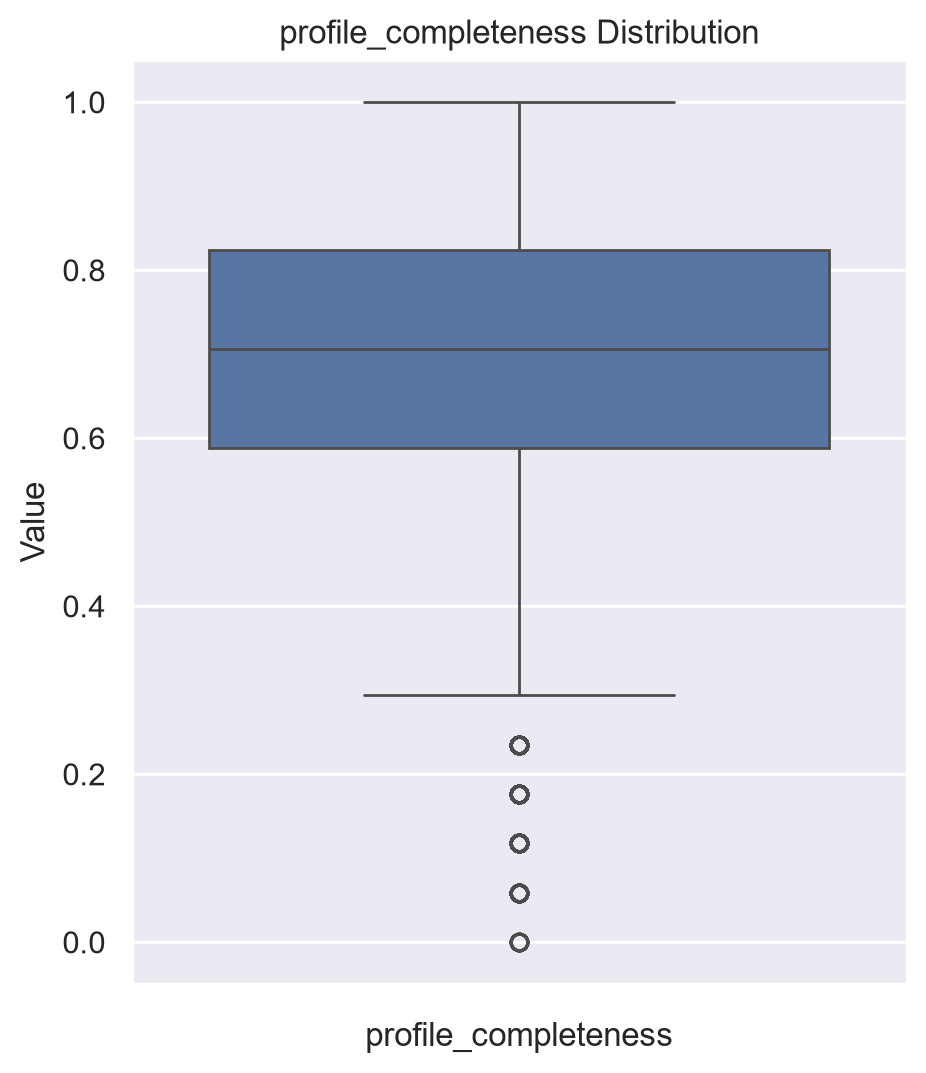

In [62]:
show_box(train["profile_completeness"])

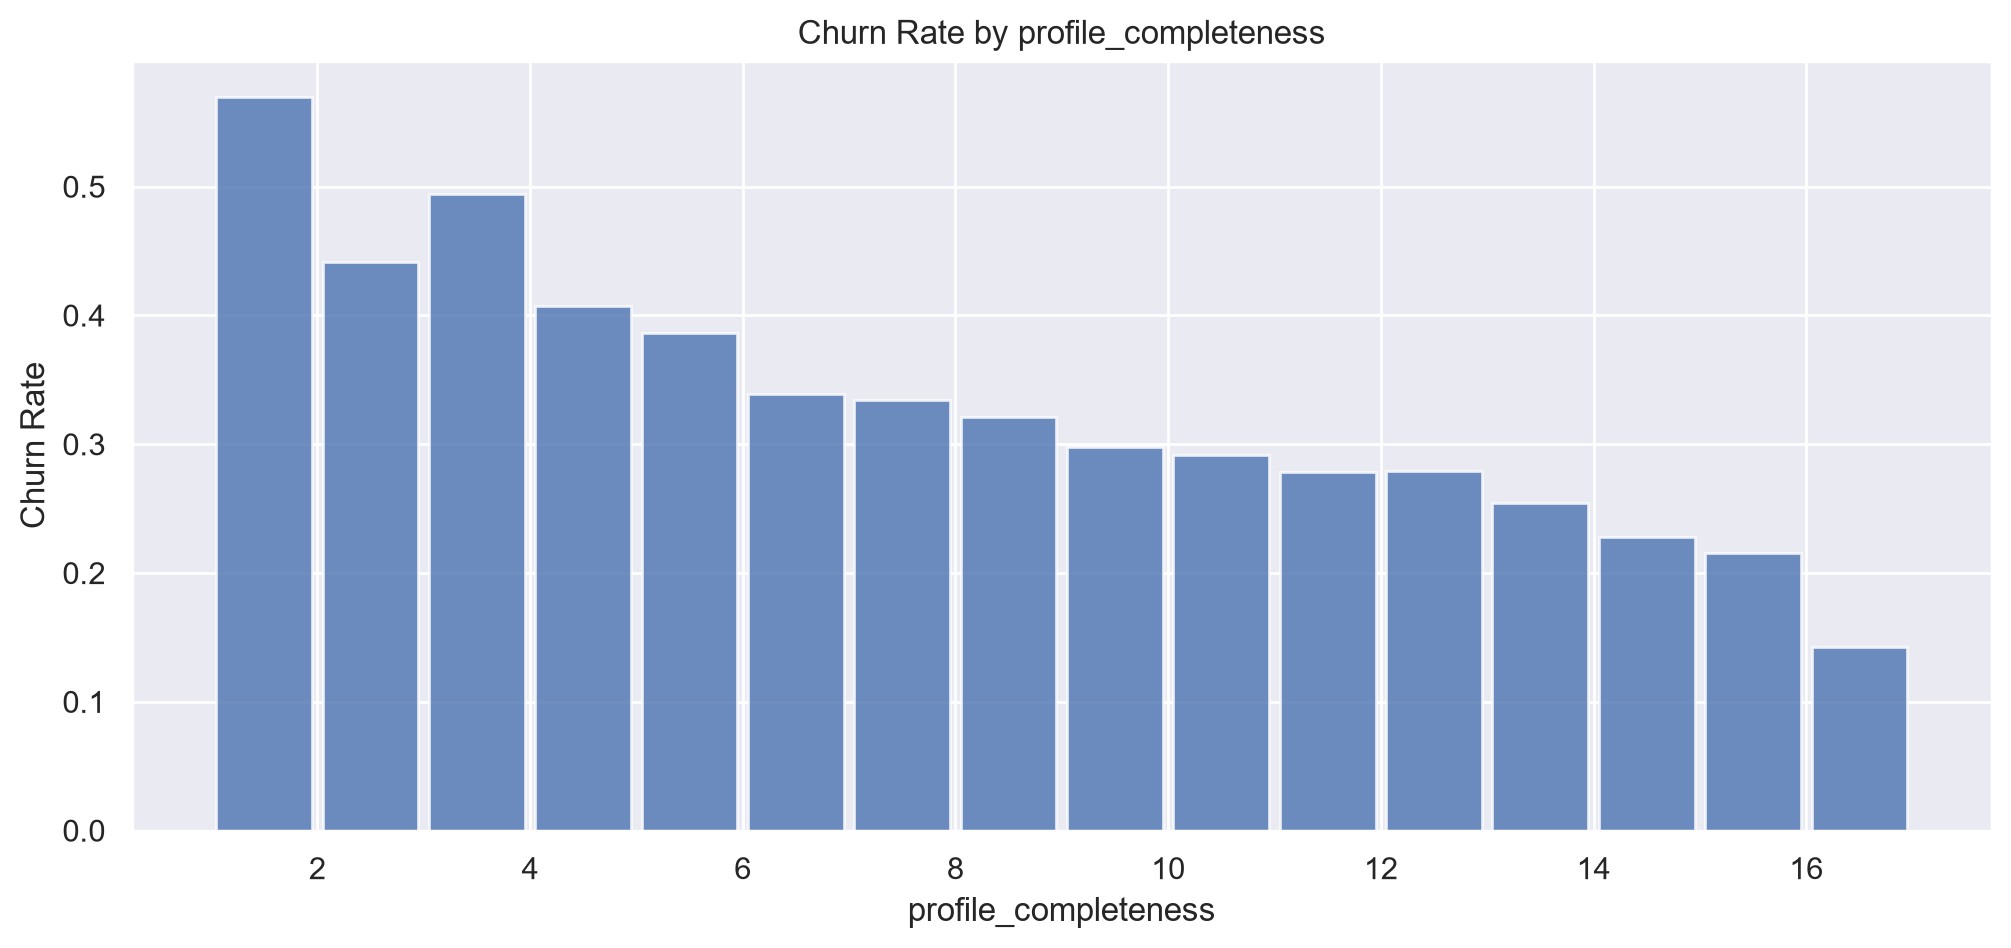

In [78]:
profile_count = (train["profile_completeness"] * 17).round().astype(int)

profile_bins = pd.cut(
    profile_count,
    bins=np.arange(1, 18),
    right=False
)
show_hist(profile_bins)